<a href="https://colab.research.google.com/github/BMOnoire/text-mining-master-project/blob/master/IRTM_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# Text Mining Project - The Hobbit
---

## Config Variables and Data

In [6]:
MODIFY_STRANGE_CHARS = True


list_of_chapters = { # given by the book's index
  "Chapter I": "AN UNEXPECTED PARTY",
  "Chapter II": "ROAST MUTTON",
  "Chapter III": "A SHORT REST",
  "Chapter IV": "OVER HILL AND UNDER HILL",
  "Chapter V": "RIDDLES IN THE DARK",
  "Chapter VI": "OUT OF THE FRYING-PAN INTO THE FIRE",
  "Chapter VII": "QUEER LODGINGS",
  "Chapter VIII": "FLIES AND SPIDERS",
  "Chapter IX": "BARRELS OUT OF BOND",
  "Chapter X": "A WARM WELCOME",
  "Chapter XI": "ON THE DOORSTEP",
  "Chapter XII": "INSIDE INFORMATION",
  "Chapter XIII": "NOT AT HOME",
  "Chapter XIV": "FIRE AND WATER",
  "Chapter XV": "THE GATHERING OF THE CLOUDS",
  "Chapter XVI": "A THIEF IN THE NIGHT",
  "Chapter XVII": "THE CLOUDS BURST",
  "Chapter XVIII": "THE RETURN JOURNEY",
  "Chapter XIX": "THE LAST STAGE"
}

---
## Import Libraries


In [7]:
import re
import string
import nltk
nltk.download("book")
import pandas as pd
import numpy as np
import string
import pprint
from nltk.stem import WordNetLemmatizer
from nltk.corpus import words
from operator import itemgetter
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import pprint
%matplotlib inline
# to see more of the sentences in pandas
#%load_ext google.colab.data_table
#%unload_ext google.colab.data_table

import spacy
from collections import Counter
import spacy.cli
spacy.cli.download("en_core_web_lg")

from google.colab import files
import random
from spacy.util import minibatch, compounding
from pathlib import Path

[nltk_data] Downloading collection 'book'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package brown to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/brown.zip.
[nltk_data]    | Downloading package chat80 to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/chat80.zip.
[nltk_data]    | Downloading package cmudict to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/cmudict.zip.
[nltk_data]    | Downloading package conll2000 to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/conll2000.zip.
[nltk_data]    | Downloading package conll2002 to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/conll2002.zip.
[nltk_data]    | Downloading package dependency_treebank to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping corpora/dependency_treebank.zip.
[nltk_data]    | Downloading package genesis to /root/nltk_data...
[nltk_data]    

---
# Upload the book and create the df
---

In [8]:
# import a repository from github

REPO_NAME = "https://github.com/BMOnoire/text-mining-master-project"
#print("IMPORT", REPO_NAME)
!rm -rf ./text-mining-master-project
!git clone $REPO_NAME

Cloning into 'text-mining-master-project'...
remote: Enumerating objects: 21, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 21 (delta 7), reused 17 (delta 3), pack-reused 0
Unpacking objects: 100% (21/21), done.


---
Clean the test
---

In [9]:
# open file and cleaned it

text = open('text-mining-master-project/the_hobbit.txt', 'r').read()

# [ \ ]  And with that Ya hoy\ the flames were under Gandalf's tree.
# [ • ■ £ ]  The Elvenking's Gate 1 p -s. Tii Tn^ir - j i ■■• * ■ — .i- -_£ 1 i/>j p'v : mm The prisoners were brought before him; and though he looked grimly at them, he told his men to unbind them, for they were ragged and weary.
# [ ¬ ]  annoyng behaviour check everytime
# [ ‘ ’ ] inner dialog???, understand what solve this issue

text = text.replace('\n', '')
text = text.replace('\\', '')
text = text.replace('¬ ', '-')
text = text.replace('The Elvenking\'s Gate 1 p -s. Tii Tn^ir - j i ■■• * ■ — .i- -_£ 1 i/>j p\'v : mm', '') # remove a lot of noisy chars, its not a part of the novel
text = text.replace('. . .','...')
text = text.replace('! ! !','!!!')
text = text.replace('. .','..')
text = text.replace('! !','!!')

if MODIFY_STRANGE_CHARS:
  text = text.replace('“', '"')
  text = text.replace('”', '"')
  text = text.replace('’', "'")
  text = text.replace('‘', "'") 

text[:200]

'THE HOBBIT TRR- TOLKIEN 75 T " ANNIVERSARY EDITION THE HOBBIT OR THERE AND BACK AGAIN BY J.R.R. TOLKIEN Houghton Mifflin Harcourt CONTENTS TITLE PAGE LIST OF ILLUSTRATIONS NOTE ON THE TEXT AUTHOR\'S NO'

In [10]:
# divide all the sentences 

sentences = nltk.sent_tokenize(text)

# select only the story

for i, sentence in enumerate(sentences):
  if re.search(r'\AChapter I AN UNEXPECTED PARTY', sentence):
    init_bound = i
  if re.search(r'said Bilbo laughing, and handed him the tobacco-jar.\Z', sentence):
    end_bound = i

sentences = sentences[init_bound:end_bound+1]

# INIT THE DATAFRAME
df = pd.DataFrame(sentences, columns=['sentence'])


print("There are", len(sentences),"sentences\n")

print("FIRST -> ", sentences[0])
print("LAST  -> ", sentences[-1])

There are 5878 sentences

FIRST ->  Chapter I AN UNEXPECTED PARTY In a hole in the ground there lived a hobbit.
LAST  ->  said Bilbo laughing, and handed him the tobacco-jar.


---
# Preprocessing Test Data
---

In [11]:
print(pd.options.display.max_colwidth)
pd.set_option('display.max_colwidth', None) # to see all the sentence

50


In [12]:
def get_test(file_name):
  t_set = open(file_name).read().splitlines()
  t_set = [element for element in t_set if element != '']
  return set(t_set)

names_set_1 = get_test('text-mining-master-project/the_hobbit_characters_wiki.txt')
#names_set_1 = set([element.replace(r'The ', '') for element in names_set_1])

names_set_2 = get_test('text-mining-master-project/the_hobbit_characters.txt')
#names_set_2 = set([element.replace(r'The ', '') for element in names_set_2])
names_set_2 = set([element.replace(r' (mentioned only)', '') for element in names_set_2])

places_set = get_test('text-mining-master-project/the_hobbit_places.txt')
#places_set = set([element.replace(r'The ', '') for element in places_set])
places_set = set([element.replace(r'Hall', 'hall') for element in places_set])


def check_element_presence(element_list):
  print("\n##########################\n")
  print("List of missing elements:\n")
  count = 0
  found_set = []
  for element in element_list:
    #print("[",element,"]\n")
    result = df[df['sentence'].str.contains(element)]['sentence']
    #pprint.pprint(result)
    #print("\nresult:",len(result))
    if len(result):
      found_set.append(element)
      count += 1
    else:      
      print(element)
    #print("\n##########################\n")
  
  print("\nFOUND =>", count, "/", len(element_list),"\n")
  print("##########################\n")
  return set(found_set)

names1_found = check_element_presence(names_set_1)
names2_found = check_element_presence(names_set_2)
places_test_data = check_element_presence(places_set)

names_test_data = names1_found.union(names2_found)

print("\nNAMES USEFUL =>", len(names_test_data), "/", len(names_set_1.union(names_set_2)),"\n")
print("\nPLACES USEFUL =>", len(places_test_data), "/", len(places_set),"\n")

print("\n##########################\n")
print("Test for names characters:\n")
pprint.pprint(names_test_data)
print("\n##########################\n")
print("Test for names of places:\n")
pprint.pprint(places_test_data)


##########################

List of missing elements:

The Master of Lake-town
Carc
Bilbo Baggins of Bag End
The Sackville-Bagginses
Dáin
The Necromancer
Roäc
The Old Took
Beorn the "skin-changer"
Chubb, Chubb, and Burrowes

FOUND => 30 / 40 

##########################


##########################

List of missing elements:

Radagast the Brown
Carc
Glóin
Roäc
Gandalf the Grey
Dáin Ironfoot
Thrór
Fíli
Thráin
Thráin I
Kíli
Óin

FOUND => 33 / 45 

##########################


##########################

List of missing elements:

Bagshot Row
Bag End
Thranduil's halls
Great hall of Thráin
Erebor
Enchanted River
Last desert
Old Forest Road
Eriador
Rhovanion
Elf-path
The Shire
Beorn's hall
Trollshaws
Westfarthing
Eagles' eyrie
Goblin town
Back Door

FOUND => 22 / 40 

##########################


NAMES USEFUL => 39 / 59 


PLACES USEFUL => 22 / 40 


##########################

Test for names characters:

{'Azog',
 'Balin',
 'Bard the Bowman',
 'Belladonna Took',
 'Beorn',
 'Bert',
 'Bifur

In [13]:
# Add Grubb, Burrowes to names
print(df[df['sentence'].str.contains("Grubb")]['sentence'])
names_test_data.add("Grubb")
names_test_data.add("Burrowes")
#pprint.pprint(names_test_data)


5830    There was a large notice in black and red hung on the gate, stating that on June the Twenty-second Messrs Grubb, Grubb, and Burrowes would sell by auction the effects of the late Bilbo Baggins Esquire, of Bag-End, Underhill, Hobbiton.
Name: sentence, dtype: object


In [14]:
# change Dain -> Dáin
print(df[df['sentence'].str.contains("Dain[^\w]")]['sentence'])
df['sentence'] = df['sentence'].str.replace("Dain", "Dáin")
names_test_data.add("Dáin")

4955                                                                                                                                    But go specially to my cousin Dain in the Iron Hills, for he has many people well-armed, and dwells nearest to this place.
5017    This song appeared to please Thorin, and he smiled again and grew merry; and he began reckoning the distance to the Iron Hills and how long it would be before Dain could reach the Lonely Mountain, if he had set out as soon as the message reached him.
5081                               Things had gone on like this for some time, when the ravens brought news that Dain and more than five hundred dwarves, hurrying from the Iron Hills, were now within about two days' march of Dale, coming from the North-East.
5170                                                                                                                                                                                                You have not heard of Dain 

In [15]:
# change Roac -> Roäc
print(df[df['sentence'].str.contains("Roac[^\w]")]['sentence'])
df['sentence'] = df['sentence'].str.replace("Roac", "Roäc")
names_test_data.add("Roäc")

4921                                                                                                                            "I am Roac son of Care.
4934                                                                       They all sprang up and began to caper about for joy- "Yes, dead," said Roac.
4950                                                                                    Then Thorin burst forth in anger: "Our thanks, Roac Care's son.
4957                                                   "I will not say if this counsel be good or bad," croaked Roac, "but I will do what can be done."
5082                                          "But they cannot reach the Mountain unmarked," said Roac, "and I fear lest there be battle in the valley.
5348    With that they went back to the camp; but Thorin sent messengers by Roac telling Dáin of what had passed, and bidding him come with wary speed.
Name: sentence, dtype: object


In [16]:
# change Care -> Carc
print(df[df['sentence'].str.contains("Care")]['sentence'])
df['sentence'] = df['sentence'].str.replace("Care", "Carc")
df['sentence'] = df['sentence'].str.replace("Carcf", "Caref")
names_test_data.add("Carc")

#print(df[df['sentence'].str.contains("Car[ce]")]['sentence'])


195                                                                                                                                               "Carefully!
196                                                                                                                                               Carefully!"
1818                                                                                                 Careful now, or this way will lead you to worse things."
2880                                                                              Fili hauled the rope back slowly, and after a while Bilbo said: "Carefully!
4911    This very height was once named Ravenhill, because there was a wise and famous pair, old Care and his wife, that lived here above the guard- chamber.
4921                                                                                                                                  "I am Roäc son of Care.
4922                                                

In [17]:
# change Thrain -> Thráin
df['sentence'] = df['sentence'].str.replace("Thrain", "Thráin")
names_test_data.add("Thráin")

In [18]:
# change Thror -> Thrór
df['sentence'] = df['sentence'].str.replace("Thror", "Thrór")
names_test_data.add("Thrór")

In [19]:
print("Test List for names characters:\n")
pprint.pprint(names_test_data)
print("\n##########################\n")
print("Test List for names of places:\n")
pprint.pprint(places_test_data)

Test List for names characters:

{'Azog',
 'Balin',
 'Bard the Bowman',
 'Belladonna Took',
 'Beorn',
 'Bert',
 'Bifur',
 'Bilbo Baggins',
 'Bofur',
 'Bolg',
 'Bombur',
 'Bullroarer Took',
 'Bungo Baggins',
 'Burrowes',
 'Carc',
 'Dori',
 'Durin',
 'Dwalin',
 'Dáin',
 'Elrond',
 'Fili',
 'Galion',
 'Gandalf',
 'Girion of Dale',
 'Gloin',
 'Golfimbul',
 'Gollum',
 'Grubb',
 'Kili',
 'Master of Lake-town',
 'Nori',
 'Oin',
 'Old Took',
 'Ori',
 'Radagast',
 'Roäc',
 'Smaug',
 'The Elvenking',
 'The Great Goblin',
 'The Lord of the Eagles',
 'Thorin Oakenshield',
 'Thráin',
 'Thrór',
 'Tom',
 'Wargs',
 'William'}

##########################

Test List for names of places:

{'Bywater',
 'Carrock',
 'Dale',
 'Desolation of the Dragon',
 'Dorwinion',
 'Esgaroth',
 'Faerie',
 'Front Gate',
 'Green Dragon',
 'Gundabad',
 'High Pass',
 'Hobbiton',
 'Iron Hills',
 'Long Lake',
 'Long Marshes',
 'Mirkwood',
 'Misty Mountains',
 'Moria',
 'Ravenhill',
 'Rivendell',
 'The Hill',
 'Withered Heath'}


---
# Preprocessing
---

In [20]:
#print(pd.options.display.max_colwidth)
pd.set_option('display.max_colwidth', 50) # to see all the sentence
#print(pd.options.display.max_colwidth)

In [21]:
# useful for graphs order
chapter_transf_dict = {
  "Chapter I": "Chapter 01",
  "Chapter II": "Chapter 02",
  "Chapter III": "Chapter 03",
  "Chapter IV": "Chapter 04",
  "Chapter V": "Chapter 05",
  "Chapter VI": "Chapter 06",
  "Chapter VII": "Chapter 07",
  "Chapter VIII": "Chapter 08",
  "Chapter IX": "Chapter 09",
  "Chapter X": "Chapter 10",
  "Chapter XI": "Chapter 11",
  "Chapter XII": "Chapter 12",
  "Chapter XIII": "Chapter 13",
  "Chapter XIV": "Chapter 14",
  "Chapter XV": "Chapter 15",
  "Chapter XVI": "Chapter 16",
  "Chapter XVII": "Chapter 17",
  "Chapter XVIII": "Chapter 18",
  "Chapter XIX": "Chapter 19"
}

def transform_chapter_RomanToNumber(chapter):
  for chap_roman, chap_number in chapter_transf_dict.items():
    if chapter == chap_roman:
      return chap_number
  return chapter

def transform_chapter_NumberToRoman(chapter):
  for chap_roman, chap_number in chapter_transf_dict.items():
    if chapter == chap_number:
      return chap_roman
  return chapter
  

In [22]:
# find chapters' first sentences
for i, sentence in enumerate(sentences):
  if re.search(r'Chapter', sentence):
    print(str(i),"\t", sentence)
    
# chapter
df['chapter'] = np.where(
    df['sentence'].str.startswith('Chapter'), 
    df['sentence'].str.split(' ').str[:2], 
    np.nan
 )
df['chapter'] = df['chapter'].str[0] + ' ' + df['chapter'].str[1]

df['chapter'] = df['chapter'].apply(lambda x: transform_chapter_RomanToNumber(x))

df.loc[df['chapter'].notnull()] # just to show all first sentences of chapters

0 	 Chapter I AN UNEXPECTED PARTY In a hole in the ground there lived a hobbit.
520 	 Chapter II ROAST MUTTON Up jumped Bilbo, and putting on his dressing-gown went into the dining-room.
886 	 Chapter III A SHORT REST They did not sing or tell stories that day, even though the weather improved; nor the next day, nor the day after.
1075 	 Chapter IV OVER HILL AND UNDER HILL There were many paths that led up into those mountains, and many passes over them.
1315 	 Chapter V RIDDLES IN THE DARK When Bilbo opened his eyes, he wondered if he had; for it was just as dark as with them shut.
1874 	 Chapter VI OUT OF THE FRYING-PAN INTO THE FIRE Bilbo had escaped the goblins, but he did not know where he was.
2260 	 Chapter VII QUEER LODGINGS The next morning Bilbo woke up with the early sun in his eyes.
2811 	 Chapter VIII FLIES AND SPIDERS They walked in single file.
3360 	 Chapter IX BARRELS OUT OF BOND The day after the battle with the spiders Bilbo and the dwarves made one last despairing e

,sentence,chapter
0,Chapter I AN UNEXPECTED PARTY In a hole in the...,Chapter 01
520,"Chapter II ROAST MUTTON Up jumped Bilbo, and p...",Chapter 02
886,Chapter III A SHORT REST They did not sing or ...,Chapter 03
1075,Chapter IV OVER HILL AND UNDER HILL There were...,Chapter 04
1315,Chapter V RIDDLES IN THE DARK When Bilbo opene...,Chapter 05
1874,Chapter VI OUT OF THE FRYING-PAN INTO THE FIRE...,Chapter 06
2260,Chapter VII QUEER LODGINGS The next morning Bi...,Chapter 07
2811,Chapter VIII FLIES AND SPIDERS They walked in ...,Chapter 08
3360,Chapter IX BARRELS OUT OF BOND The day after t...,Chapter 09
3650,Chapter X A WARM WELCOME The day grew lighter ...,Chapter 10


In [23]:
# chapter name
df['chapter_name'] = df['sentence'].str.extract(r'\AChapter [A-Z]* ([A-Z\s\-]+) ')

# remove all the titles in caps lock from sentences
df['sentence'] = df['sentence'].str.replace(r'\AChapter [A-Z\s\-]+ ', '')

df.loc[df['chapter'].notnull()] # just to show all first sentences of chapters

,sentence,chapter,chapter_name
0,In a hole in the ground there lived a hobbit.,Chapter 01,AN UNEXPECTED PARTY
520,"Up jumped Bilbo, and putting on his dressing-g...",Chapter 02,ROAST MUTTON
886,"They did not sing or tell stories that day, ev...",Chapter 03,A SHORT REST
1075,There were many paths that led up into those m...,Chapter 04,OVER HILL AND UNDER HILL
1315,"When Bilbo opened his eyes, he wondered if he ...",Chapter 05,RIDDLES IN THE DARK
1874,"Bilbo had escaped the goblins, but he did not ...",Chapter 06,OUT OF THE FRYING-PAN INTO THE FIRE
2260,The next morning Bilbo woke up with the early ...,Chapter 07,QUEER LODGINGS
2811,They walked in single file.,Chapter 08,FLIES AND SPIDERS
3360,The day after the battle with the spiders Bilb...,Chapter 09,BARRELS OUT OF BOND
3650,The day grew lighter and warmer as they floate...,Chapter 10,A WARM WELCOME


In [24]:
df.fillna(method='ffill', inplace=True) # fill Nan values with the not null chapter element before them
print(df.loc[df['chapter'].isnull()]) # check if there is something wrong
df.dropna(inplace=True) #clean all possible "something went wrong"

Empty DataFrame
Columns: [sentence, chapter, chapter_name]
Index: []


In [25]:
# PRECISION / RECALL / F1

unique_chapters = set(df["chapter"].unique())
unique_names = set(df["chapter_name"].unique())
#print(unique_chapters)
#print(unique_names)
test_chapters = {transform_chapter_RomanToNumber(k) for k, _ in list_of_chapters.items()}
test_names = {n for _, n in list_of_chapters.items()}
#print(test_chapters)
#print(test_chapters)



def evaluation_function(selected_set, relevant_set, show_match = False):
  true_positive_list = selected_set.intersection(relevant_set)
  if show_match:
    print("Found n elelments:", len(true_positive_list))
    pprint.pprint(true_positive_list)
  print(len(true_positive_list),"precision", len(selected_set))
  print(len(true_positive_list),"recall", len(relevant_set))
  precision = len(true_positive_list) / len(selected_set)
  recall = len(true_positive_list) / len(relevant_set)
  f1 = 0
  if precision + recall != 0:
    f1 = (2*precision*recall) / (precision + recall)
  return precision, recall, f1

eval_chapter = evaluation_function(unique_chapters, test_chapters)
eval_names = evaluation_function(unique_names, test_names)

print("PREC-RECALL-F1 chapter:", eval_chapter)
print("PREC-RECALL-F1 names:", eval_names)



19 precision 19
19 recall 19
19 precision 19
19 recall 19
PREC-RECALL-F1 chapter: (1.0, 1.0, 1.0)
PREC-RECALL-F1 names: (1.0, 1.0, 1.0)


In [26]:
#normalization

# clean senteces from punctuation
string.punctuation += '“”‘’—¬'
translator = str.maketrans(string.punctuation, ' '*len(string.punctuation)) # prefer to translate in space to avoid that a word is wrongly connected to another
df['cleaned_sentence'] = df['sentence'].apply(lambda x: x.translate(translator))

# removes the beginning and ending spaces
df['cleaned_sentence'] = df['cleaned_sentence'].str.strip()

# till exists a double space inside the sentence it turns it into one
double_space_exist = max(df['cleaned_sentence'].str.count("  "))
while double_space_exist:
  double_space_exist = max(df['cleaned_sentence'].str.count("  ")) 
  print("There is at least one sentence with", double_space_exist, "double space")
  df['cleaned_sentence'] = df['cleaned_sentence'].str.replace('  ', ' ')

#print(df['sentence'].loc[2430])
#print(df['sentence'].loc[2431])
#print(df['sentence'].loc[2432])

# avoid that there is a cleaned sentence void
for i in range(len(df)):
    if df['cleaned_sentence'].loc[i] == '':
        print(str(i), '->', df['sentence'].loc[i])
        df['cleaned_sentence'].loc[i] = 'none'

df.head(10)

There is at least one sentence with 18 double space
There is at least one sentence with 5 double space
There is at least one sentence with 1 double space
There is at least one sentence with 0 double space


,sentence,chapter,chapter_name,cleaned_sentence
0,In a hole in the ground there lived a hobbit.,Chapter 01,AN UNEXPECTED PARTY,In a hole in the ground there lived a hobbit
1,"Not a nasty, dirty, wet hole, filled with the ...",Chapter 01,AN UNEXPECTED PARTY,Not a nasty dirty wet hole filled with the end...
2,"It had a perfectly round door like a porthole,...",Chapter 01,AN UNEXPECTED PARTY,It had a perfectly round door like a porthole ...
3,The door opened on to a tube-shaped hall like ...,Chapter 01,AN UNEXPECTED PARTY,The door opened on to a tube shaped hall like ...
4,"The tunnel wound on and on, going fairly but n...",Chapter 01,AN UNEXPECTED PARTY,The tunnel wound on and on going fairly but no...
5,"No going upstairs for the hobbit: bedrooms, ba...",Chapter 01,AN UNEXPECTED PARTY,No going upstairs for the hobbit bedrooms bath...
6,The best rooms were all on the left-hand side ...,Chapter 01,AN UNEXPECTED PARTY,The best rooms were all on the left hand side ...
7,"This hobbit was a very well-to-do hobbit, and ...",Chapter 01,AN UNEXPECTED PARTY,This hobbit was a very well to do hobbit and h...
8,The Bagginses had lived in the neighbourhood o...,Chapter 01,AN UNEXPECTED PARTY,The Bagginses had lived in the neighbourhood o...
9,This is a story of how a Baggins had an advent...,Chapter 01,AN UNEXPECTED PARTY,This is a story of how a Baggins had an advent...


---
# Text Analysis
---

In [27]:
pd.set_option('display.max_colwidth', None) # to see all the sentence

In [28]:
nlp = spacy.load("en_core_web_lg")
nlp.pipe_names

['tagger', 'parser', 'ner']

In [30]:
def get_pprn(list_name):
  pprn_list = []
  for name in list_name:
    #name.
    #if name.replace("the"):
    #  print(name)
    if re.search("\Athe", name):
      #print(name)
      pprn_list.append(name.replace("the", "The", 1))
    elif re.search("\A[A-Z]", name):
      pprn_list.append(name)

  return set(pprn_list)



def get_entity_set(column):
  unique_list = []
  for i in range(len(df)):
      unique_list += [x for x in df[column].iloc[i]]
  return  get_pprn(unique_list)


In [31]:
#%%script false --no-raise-error
def get_count_of_object(sentence_list):
  tokens = nlp(''.join(str(sentence_list)))
  #pprint.pprint(tokens)

  items = [(x.text, x.label_) for x in tokens.ents]
  #pprint.pprint(items)

  #pprint.pprint(Counter(items).most_common(20))

  person_list = []
  for ent in tokens.ents:
    #print(ent.label_)
    if ent.label_ == 'PERSON':
        person_list.append(ent.text)
        
  person_counts = Counter(person_list).most_common(20)
  pprint.pprint(person_counts)

get_count_of_object(df.sentence.tolist())

[('Bilbo', 528),
 ('Thorin', 231),
 ('Gandalf', 168),
 ('Baggins', 76),
 ('Gollum', 75),
 ('Balin', 67),
 ('Fili', 50),
 ('Kili', 36),
 ('Bard', 35),
 ('Dori', 34),
 ('Dale', 31),
 ('Bert', 28),
 ('William', 26),
 ('Elrond', 23),
 ('Tom', 20),
 ('Oin', 18),
 ('Bilbo Baggins', 17),
 ('Bombur', 16),
 ('Arkenstone', 14),
 ('Nori', 12)]


In [34]:
df['token_list'] = df['sentence'].apply(lambda x: nlp(x))
#df['token_list_1'] = df['cleaned_sentence'].apply(lambda x: nlp(x))

df['named_entities'] = df['token_list'].apply(lambda x: x.ents)

#lambda x: [element for element in x if element.lower() not in words.words() ]
df['characters'] = df['named_entities'].apply(lambda x: [ent.text for ent in x if ent.label_ == "PERSON"])
unique_characters = get_entity_set('characters')
print("Characters test PERSON:")
print(evaluation_function(unique_characters, names_test_data, True))

print("##################################################################")
df['characters'] = df['named_entities'].apply(lambda x: [ent.text for ent in x if ent.label_ == "PERSON" or ent.label_ == "ORG"])
unique_characters = get_entity_set('characters')
print("Characters test PERSON+ORG:")
print(evaluation_function(unique_characters, names_test_data, True))

df['places'] = df['named_entities'].apply(lambda x: [ent.text for ent in x if ent.label_ == "LOC"])

Characters test PERSON:
Found n elelments: 33
{'Balin',
 'Belladonna Took',
 'Beorn',
 'Bert',
 'Bifur',
 'Bilbo Baggins',
 'Bofur',
 'Bombur',
 'Bullroarer Took',
 'Bungo Baggins',
 'Dori',
 'Durin',
 'Dwalin',
 'Dáin',
 'Elrond',
 'Fili',
 'Gandalf',
 'Gloin',
 'Golfimbul',
 'Gollum',
 'Grubb',
 'Kili',
 'Nori',
 'Oin',
 'Ori',
 'Radagast',
 'Roäc',
 'The Lord of the Eagles',
 'Thorin Oakenshield',
 'Thráin',
 'Thrór',
 'Tom',
 'William'}
33 precision 109
33 recall 46
(0.30275229357798167, 0.717391304347826, 0.42580645161290326)
##################################################################
Characters test PERSON+ORG:
Found n elelments: 41
{'Balin',
 'Belladonna Took',
 'Beorn',
 'Bert',
 'Bifur',
 'Bilbo Baggins',
 'Bofur',
 'Bolg',
 'Bombur',
 'Bullroarer Took',
 'Bungo Baggins',
 'Burrowes',
 'Carc',
 'Dori',
 'Durin',
 'Dwalin',
 'Dáin',
 'Elrond',
 'Fili',
 'Galion',
 'Gandalf',
 'Gloin',
 'Golfimbul',
 'Gollum',
 'Grubb',
 'Kili',
 'Nori',
 'Oin',
 'Old Took',
 'Ori',
 'Rad

In [35]:
for token in df['token_list'][0]:
    print(token.text, token.pos_, token.dep_)

In ADP prep
a DET det
hole NOUN pobj
in ADP prep
the DET det
ground NOUN pobj
there ADV expl
lived VERB ROOT
a DET det
hobbit NOUN dobj
. PUNCT punct


In [36]:
doc = df['token_list'][4]
spacy.displacy.render(doc, style='dep', jupyter=True, options={"compact": True, 'distance': 100})

In [37]:
doc = df['token_list'][18]
spacy.displacy.render(doc, style='ent', jupyter=True, options={})

In [38]:
unique_characters = get_entity_set('characters')
unique_characters

{'Alder',
 'Arkenstone',
 'Arrows',
 'Asa',
 'Avery',
 'Bag-End',
 'Baggins',
 'Bagginses',
 'Bake',
 'Balin',
 'Bard',
 'Barrel',
 'Belladonna',
 'Belladonna Took',
 "Belladonna Took's",
 'Beorn',
 'Bert',
 'Bifur',
 'Bilbo',
 'Bilbo Baggins',
 'Bilbo Baggins Esquire',
 'Bilbo plumped',
 'Bill',
 'Bill Huggins',
 'Blue',
 'Bofur',
 'Bolg',
 'Bombur',
 'Bullroarer',
 'Bullroarer Took',
 'Bungo',
 'Bungo Baggins',
 'Burrowes',
 'Bywater',
 'Carc',
 'Carrock',
 'Cob',
 'Confusticate',
 'Cross',
 'Dale',
 'Dale rebuilt',
 'Dawn',
 'Dori',
 'Dorks',
 'Dragon',
 'Dread',
 'Durin',
 'Dwalin',
 'Dwarves',
 'Dáin',
 'Eagles',
 'Eggses',
 'Elrond',
 'Elvenking',
 'Elves',
 'Eyrie',
 'Fili',
 'Forest',
 'Front Porch',
 'Galion',
 'Gandalf',
 'Gandalf Tea',
 'Gate',
 'Girion',
 'Girion Lord of Dale',
 'Glamdring',
 'Gloin',
 'Goblins',
 'Golfimbul',
 'Gollum',
 'Gollum Bilbo',
 'Gondolin',
 'Grubb',
 'Gundabad',
 'Hammer',
 'Hammers',
 'Handses',
 'Hill',
 'Ho',
 'Hobbiton',
 'Invisible Baggins',

In [39]:
unique_places = get_entity_set('places')
unique_places

{'Beorn',
 'Bofur',
 'Earth',
 'East',
 'Forest River',
 'Homely House',
 'Lake',
 'Lake-town',
 'Lonely Mountain',
 'Longbeards',
 'Misty Mountains',
 'Mount Gram',
 'Mountain',
 'Mountains',
 'North',
 'North-East',
 'South',
 'South-East',
 'South-West',
 'The East of East',
 'The Forest River',
 'The Great River',
 'The Grey Mountains',
 'The Hill',
 'The Iron Hills',
 'The Last Desert',
 'The Lonely Mountain',
 'The Long Lake',
 'The Lorest River',
 'The Misty Mountains',
 'The Mountain',
 'The River Running',
 'The Running River',
 'The black East',
 'The misty mountains',
 'Tomnoddy',
 'Tra-la-la-lally Fa-la-la-lally Fa-la',
 'Under-Hill',
 'Valley',
 'West',
 'Western Land'}

In [40]:
# test all together to see if it's ok

print("Characters test:")
print(evaluation_function(unique_characters, names_test_data, True))
print("\nPlaces test:")
print(evaluation_function(unique_places, places_test_data, True))

Characters test:
Found n elelments: 41
{'Balin',
 'Belladonna Took',
 'Beorn',
 'Bert',
 'Bifur',
 'Bilbo Baggins',
 'Bofur',
 'Bolg',
 'Bombur',
 'Bullroarer Took',
 'Bungo Baggins',
 'Burrowes',
 'Carc',
 'Dori',
 'Durin',
 'Dwalin',
 'Dáin',
 'Elrond',
 'Fili',
 'Galion',
 'Gandalf',
 'Gloin',
 'Golfimbul',
 'Gollum',
 'Grubb',
 'Kili',
 'Nori',
 'Oin',
 'Old Took',
 'Ori',
 'Radagast',
 'Roäc',
 'Smaug',
 'The Great Goblin',
 'The Lord of the Eagles',
 'Thorin Oakenshield',
 'Thráin',
 'Thrór',
 'Tom',
 'Wargs',
 'William'}
41 precision 173
41 recall 46
(0.23699421965317918, 0.8913043478260869, 0.37442922374429227)

Places test:
Found n elelments: 2
{'Misty Mountains', 'The Hill'}
2 precision 41
2 recall 22
(0.04878048780487805, 0.09090909090909091, 0.06349206349206349)


without ORG -> 0.30275229357798167, 0.717391304347826, 0.42580645161290326


with ORG -> 0.23699421965317918,   0.8913043478260869,   0.37442922374429227

---
Training NER
---

In [41]:
df['sentence_length'] = df['sentence'].apply(lambda x: len(x.split(' ')))

In [42]:
# take random sentences with at least 1 ORG

#ne_size = df['named_entities'].apply(lambda x: len(x))
df_train = df
df_train['orgs'] = df['named_entities'].apply(lambda x: len([ent.text for ent in x if ent.label_ == "ORG"]))
df_train = df.loc[df['orgs'] != 0, ["sentence"]]
#df["sentence"]
df_train = df_train.sample(100, random_state = 0)

sentence_list = [ x for x in df_train["sentence"]]
#print(sentence_list)

with open('training_list_1.txt', 'w') as f:
    #f.write( df_train.to_string(header = False, index = False) )
    for item in sentence_list:
        f.write("%s\n" % item)

files.download('training_list_1.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [43]:
#with open('text-mining-master-project/training_sentence_list.txt') as f:
#    training_sentence_list = f.read().splitlines()
#pprint.pprint(training_sentence_list)

In [44]:
def get_ne(nlp_model, text):
  doc = nlp_model(text)
  return [(ent.text, ent.label_) for ent in doc.ents]

In [45]:
test_sentence = df['sentence'][18]
# Load pre-existing spacy model
nlp_sm = spacy.load('en_core_web_sm')
print("TEST SM Entities:", get_ne(nlp_sm, test_sentence))

nlp_lg = spacy.load('en_core_web_lg')
print("TEST LG Entities:", get_ne(nlp_lg, test_sentence))

#nlp_nw = spacy.blank("en")
#nlp_nw.add_pipe(nlp.create_pipe('ner'))
#nlp_nw.begin_training()
#print("TEST NW Entities:", get_ne(nlp_nw, test_sentence))

# training data
TRAIN_DATA = [
('"So I can well believe," said Smaug, "but that is hardly your usual name."', {'entities': [(30, 35, 'PERSON')]}),
('In this hall we can rest sound and safe, but I warn you all not to forget what Beorn said before he left us: you must not stray outside until the sun is up, on your peril."', {'entities': [(79, 84, 'PERSON')]}), 
('I had not gone very far, however, when I met a couple of friends of mine from Rivendell."', {'entities': [(78, 87, 'LOC')]}), 
('Dori, Nori, Ori, Oin, and Gloin were their names; and very soon two purple hoods, a grey hood, a brown hood, and a white hood were hanging on the pegs, and off they marched with their broad hands stuck in their gold and silver belts to join the others.', {'entities': [(26, 31, 'PERSON'), (17, 20, 'PERSON'), (12, 15, 'PERSON'), (6, 10, 'PERSON'), (0, 4, 'PERSON')]}), 
('whose father you slew in Moria.', {'entities': [(25, 30, 'LOC')]}), 
('Soon after midday they ate with Beorn for the last time, and after the meal they mounted the steeds he was lending them, and bidding him many farewells they rode off through his gate at a good pace.', {'entities': [(32, 37, 'PERSON')]}), 
('In this way they learned that the Elvenking had turned aside to the Lake, and they still had a breathing space.', {'entities': [(30, 43, 'PERSON')]}),
('"And next year after that," said Dwalin, "and our beards will grow till they hang down the cliff to the valley before anything happens here.', {'entities': [(33, 39, 'PERSON')]}),
('Don\'t stray off the track!—if you do, it is a thousand to one you will never find it again and never get out of Mirkwood; and then I don\'t suppose I, or any one else, will ever see you again."', {'entities': [(112, 120, 'LOC')]}),
('Dwalin and Balin said: "Excuse me, I left mine in the porch!"', {'entities': [(11, 16, 'PERSON'), (0, 6, 'PERSON')]}), ('Above the borders of the Forest there was whistling, crying and piping.', {'entities': [(21, 31, 'LOC')]}),
('"And why is it called the Carrock?"', {'entities': [(26, 33, 'LOC')]}), 
('Coming to a rise he could see his own Hill in the distance, and he stopped suddenly and said: Roads go ever ever on, Over rock and under tree, By caves where never sun has shone, By streams that never find the sea; Over snow by winter sown, And through the merry flowers of June, Over grass and over stone, And under mountains in the moon.', {'entities': [(38, 42, 'LOC')]}), 
('There was life in Bombur still.', {'entities': [(18, 24, 'PERSON')]}), 
("He looked both sad and grim as he said this: he had been one of Thorin's companions on the day the Dragon came.", {'entities': [(64, 70, 'PERSON')]}), 
('He was guided to a safe ford and set across dry, and then he said farewell to the elves and climbed carefully back towards the Gate.', {'entities': [(123, 131, 'LOC')]}), 
('why did we not remember Beorn\'s advice, and Gandalf\'s!"', {'entities': [(44, 51, 'PERSON'), (24, 29, 'PERSON')]}), 
('Still elves are light-footed, and though they were not in these days much used to the marches and the treacherous lands between the Forest and the Lake, their going was swift.', {'entities': [(143, 151, 'LOC'), (128, 138, 'LOC')]}), 
('Some turned swiftly back, and the others after gazing for a while at the Gate and its defences soon followed them.', {'entities': [(69, 77, 'LOC')]}), 
('Only Bombur was there, for it was his turn to watch, and the dwarves kept only one watchman at a time.', {'entities': [(5, 11, 'PERSON')]}), 
('Before you could get round Mirkwood in the North you would be right among the slopes of the Grey Mountains, and they are simply stiff with goblins, hobgoblins, and ores of the worst description.', {'entities': [(88, 106, 'LOC'), (27, 35, 'LOC')]}), 
('You have not heard of Dáin and the dwarves of the Iron Hills?"', {'entities': [(50, 60, 'LOC')]}), 
('As I was saying, the mother of this hobbit—of Bilbo Baggins, that is—was the famous Belladonna Took, one of the three remarkable daughters of the Old Took, head of the hobbits who lived across The Water, the small river that ran at the foot of The Hill.', {'entities': [(244, 252, 'LOC'), (193, 202, 'LOC'), (146, 154, 'PERSON'), (84, 99, 'PERSON'), (46, 59, 'PERSON')]}), 
('"And Thráin your father went away on the twenty-first of April, a hundred years ago last Thursday, and has never been seen by you since—" "True, true," said Thorin.', {'entities': [(157, 163, 'PERSON'), (5, 11, 'PERSON')]}), 
('said Beorn, who was never very polite.', {'entities': [(5, 10, 'PERSON')]}),
('"It is time for us to sleep," he said, "—for us, but not I think for Beorn.', {'entities': [(69, 74, 'PERSON')]}), 
('He was a descendant in long line of Girion, Lord of Dale, whose wife and child had escaped down the Running River from the ruin long ago.', {'entities': [(96, 113, 'LOC'), (52, 56, 'LOC'), (36, 42, 'PERSON')]}), 
('said Bifur, Bofur, and Bombur standing in a row.', {'entities': [(23, 29, 'PERSON'), (12, 17, 'PERSON'), (5, 10, 'PERSON')]}), ('Fili hauled the rope back slowly, and after a while Bilbo said: "Carefully!', {'entities': [(52, 57, 'PERSON'), (0, 4, 'PERSON')]}),
('"Beorn is not as far off as you seem to think, and you had better keep your promises anyway, for he is a bad enemy.', {'entities': [(1, 6, 'PERSON')]}),
('"Ere long now," Gandalf was saying, "the Forest will grow somewhat more wholesome.', {'entities': [(37, 47, 'LOC'), (16, 23, 'PERSON')]}),
("But all the men of arms who were still able, and the most of the Elvenking's array, got ready to march north to the Mountain.", {'entities': [(112, 124, 'LOC'), (61, 74, 'PERSON')]}),
('Dwalin had just scrambled out with the coiled rope on his arm, and Bombur (still grumbling) was getting ready to follow, when something bad did happen.', {'entities': [(67, 73, 'PERSON'), (0, 6, 'PERSON')]}),
("All the time they ate, Beorn in his deep rolling voice told tales of the wild lands on this side of the mountains, and especially of the dark and dangerous wood, that lay outstretched far to North and South a day's ride before them, barring their way to the East, the terrible forest of Mirkwood.", {'entities': [(287, 295, 'LOC'), (23, 28, 'PERSON')]}),
('One of his elder cousins (on the Took side), who had been a great traveller, used to imitate it to frighten him.', {'entities': [(33, 37, 'PERSON')]}),
('Far over Mirkwood tidings spread: "Smaug is dead!"', {'entities': [(35, 40, 'PERSON'), (9, 17, 'LOC')]}),
('said Bombur.', {'entities': [(5, 11, 'PERSON')]}),
('Bilbo found himself running round and round (as he thought) and calling and calling: "Dori, Nori, Ori, Oin, Gloin, Fili, Kili, Bombur, Bifur, Bofur, Dwalin, Balin, Thorin Oakenshield," while people he could not see or feel were doing the same all round him (with an occasional "Bilbo!"', {'entities': [(278, 283, 'PERSON'), (164, 182, 'PERSON'), (157, 162, 'PERSON'), (149, 155, 'PERSON'), (142, 147, 'PERSON'), (135, 140, 'PERSON'), (127, 133, 'PERSON'), (121, 125, 'PERSON'), (115, 119, 'PERSON'), (108, 113, 'PERSON'), (103, 106, 'PERSON'), (98, 101, 'PERSON'), (92, 96, 'PERSON'), (86, 90, 'PERSON'), (0, 5, 'PERSON')]}),
('But fairest of all was the great white gem, which the dwarves had found beneath the roots of the Mountain, the Heart of the Mountain, the Arkenstone of Thráin.', {'entities': [(152, 158, 'PERSON'), (138, 148, 'WORK_OF_ART'), (120, 132, 'LOC'), (93, 105, 'LOC')]}),
("Beside them a pony pushed two low-seated benches with wide msh-bottoms and little short thick legs for Gandalf and Thorin, while at the far end he put Beorn's big black chair of the same sort (in which he sat with his great legs stuck far out under the table).", {'entities': [(151, 156, 'PERSON'), (115, 121, 'PERSON'), (103, 110, 'PERSON')]}), ("Each one of his folk was clad in a hauberk of steel mail that hung to his knees, and his legs were covered with hose of a fine and flexible metal mesh, the secret of whose making was possessed by Dáin's people.", {'entities': [(196, 200, 'PERSON')]}),
('Half a dozen were killed before the rest drew off and left Bombur to Bilbo.', {'entities': [(69, 74, 'PERSON'), (59, 65, 'PERSON')]}),
('"And raspberry jam and apple-tart," said Bifur.', {'entities': [(41, 46, 'PERSON')]}),
('He scattered the bodyguard, and pulled down Bolg himself and crushed him.', {'entities': [(44, 48, 'PERSON')]}),
('This, Thorin, the runes name Orcrist, the Goblin-cleaver in the ancient tongue of Gondolin; it was a famous blade.', {'entities': [(82, 90, 'LOC'), (29, 36, 'WORK_OF_ART'), (6, 12, 'PERSON')]}),
('If you lived near the edge of Mirkwood, you would take the word of no one that you did not know as well as your brother or better.', {'entities': [(30, 38, 'LOC')]}),
('After that Kili and Oin and Gloin and Dori; next Ori and Nori, Bifur and Bofur; and last Dwalin and Bombur."', {'entities': [(100, 106, 'PERSON'), (89, 95, 'PERSON'), (73, 78, 'PERSON'), (63, 68, 'PERSON'), (57, 61, 'PERSON'), (49, 52, 'PERSON'), (38, 42, 'PERSON'), (28, 33, 'PERSON'), (20, 23, 'PERSON'), (11, 15, 'PERSON')]}),
('Gandalf, too, was lying down after doing his part in setting the fire going, since Oin and Gloin had lost their tinder-boxes.', {'entities': [(91, 96, 'PERSON'), (83, 86, 'PERSON'), (0, 7, 'PERSON')]}),


("Girion Lord of Dale is dead, and I have eaten his people like a wolf among sheep, and where are his sons' sons that dare approach me?", {'entities': [(15, 19, 'LOC'), (0, 6, 'PERSON')]}),
 ('But help came swiftly; for Bard at once had speedy messengers sent up the river to the Forest to ask the aid of the King of the Elves of the Wood, and these messengers had found a host already on the move, although it was then only the third day after the fall of Smaug.', {'entities': [(264, 269, 'PERSON'), (83, 93, 'LOC'), (27, 31, 'PERSON')]}),
 ('From that portion Bard will himself contribute to the aid of Esgaroth; but if Thorin would have the friendship and honour of the lands about, as his sires had of old, then he will give also somewhat of his own for the comfort of the men of the Lake."', {'entities': [(240, 248, 'LOC'), (78, 84, 'PERSON'), (61, 69, 'LOC'), (18, 22, 'PERSON')]}),
 ('growled Beorn.', {'entities': [(8, 13, 'PERSON')]}),
 ('I am Ringwinner and Luckwearer; and I am Barrel-rider," went on Bilbo beginning to be pleased with his riddling.', {'entities': [(64, 69, 'PERSON')]}),
 ('"Don\'t start the argument all over again, Bill," he said, "or it will take all night."', {'entities': [(42, 46, 'PERSON')]}),
 ('"Now I wonder what on earth Smaug is playing at," he said.', {'entities': [(28, 33, 'PERSON')]}),
 ("He charged the ranks of the goblins of Mount Gram in the Battle of the Green Fields, and knocked their king Golfimbul's head clean off with a wooden club.", {'entities': [(108, 117, 'PERSON'), (67, 83, 'LOC'), (39, 49, 'LOC')]}),
 ('said Beorn.', {'entities': [(5, 10, 'PERSON')]}),
 ('Soon after midday they ate with Beorn for the last time, and after the meal they mounted the steeds he was lending them, and bidding him many farewells they rode off through his gate at a good pace.', {'entities': [(32, 37, 'PERSON')]}),
 ('"Some four, I should say by the sound," said Fili.', {'entities': [(45, 49, 'PERSON')]}),
 ('"Old Smaug is weary and asleep," he thought.', {'entities': [(5, 10, 'PERSON')]}),
 ('Nothing they could say would stop him; so an escort was provided for him, and as he went both the king and Bard saluted him with honour.', {'entities': [(107, 111, 'PERSON')]}),
 ('No one had dared to give battle to him for many an age; nor would they have dared now, if it had not been for the grim-voiced man (Bard was his name), who ran to and fro cheering on the archers and urging the Master to order them to fight to the last arrow.', {'entities': [(131, 135, 'PERSON'), (209, 215, 'PERSON')]}), 
 ('Then Smaug spoke.', {'entities': [(5, 10, 'PERSON')]}),
 ('"Farewell, Balin!"', {'entities': [(11, 16, 'PERSON')]}),
 ('He picked up the hobbit and laughed: "Not eaten up by Wargs or goblins or wicked bears yet I see"; and he poked Mr. Baggins\' waistcoat most disrespectfully.', {'entities': [(116, 123, 'PERSON'), (54, 59, 'PERSON')]}),
 ('At length when he had told all the tale of the battle he went on: "So much for joy, Thorin Oakenshield.', {'entities': [(84, 102, 'PERSON')]}),
 ('Another swoop and another, and another house and then another sprang afire and fell; and still no arrow hindered Smaug or hurt him more than a fly from the marshes.', {'entities': [(113, 118, 'PERSON')]}),
 ('Their ponies were lost or killed, and they would have to wait some time before Smaug relaxed his watch sufficiently for them to dare the long way on foot.', {'entities': [(79, 84, 'PERSON')]}),
 ('"That is Mr. Baggins, a hobbit of good family and unimpeachable reputation," said Gandalf.', {'entities': [(82, 89, 'PERSON'), (13, 20, 'PERSON')]}),
 ('"And I suppose we ought to thank our stars and Mr. Baggins.', {'entities': [(51, 58, 'PERSON')]}),
 ('said William, who thought it was Bert that had spoken.', {'entities': [(33, 37, 'PERSON'), (5, 12, 'PERSON')]}),
 ('"Not much use, if we have been seen coming here," said Dori, who was always looking up towards the Mountain\'s peak, as if he expected to see Smaug perched there like a bird on a steeple.', {'entities': [(141, 146, 'PERSON'), (95, 107, 'LOC'), (55, 59, 'PERSON')]}),
 ('For a long time the dwarves stood in the dark before the door and debated, until at last Thorin spoke: "Now is the time for our esteemed Mr. Baggins, who has proved himself a good companion on our long road, and a hobbit full of courage and resource far exceeding his size, and if I may say so possessed of good luck far exceeding the usual allowance—now is the time for him to perform the service for which he was included in our Company; now is the time for him to earn his Reward."', {'entities': [(141, 148, 'PERSON'), (89, 95, 'PERSON')]}),
 ('Fili and Kili looked uncomfortable and stood on one leg, but the others made no pretence of offering—except old Balin, the lookout man, who was rather fond of the hobbit.', {'entities': [(112, 117, 'PERSON'), (9, 13, 'PERSON'), (0, 4, 'PERSON')]}),
 ('To think that I should have lived to be good- morninged by Belladonna Took\'s son, as if I was selling buttons at the door!"', {'entities': [(59, 74, 'PERSON')]}),
 ('Now Bard was fighting to defend the Eastern spur, and yet giving slowly back; and the elf-lords were at bay about their king upon the southern arm, near to the watch-post on Ravenhill.', {'entities': [(174, 183, 'LOC'), (4, 8, 'PERSON')]}),
 ('Many a time afterwards the Baggins part regretted what he did now, and he said to himself: "Bilbo, you were a fool; you walked right in and put your foot in it."', {'entities': [(92, 97, 'PERSON'), (27, 34, 'PERSON')]}),
 ('"I think you did very well, if you ask me—you found out one very useful thing at any rate, and got home alive, and that is more than most can say who have had words with the likes of Smaug.', {'entities': [(183, 188, 'PERSON')]}),
 ('"Girion was lord of Dale, not king of Esgaroth," he said.', {'entities': [(38, 46, 'LOC'), (20, 24, 'LOC'), (1, 7, 'PERSON')]}),
 ('The end of their argument was that they sent Fili and Kili to look for a better shelter.', {'entities': [(54, 58, 'PERSON'), (45, 49, 'PERSON')]}),
 ('I used to see him now and again," said Beorn.', {'entities': [(39, 44, 'PERSON')]}),
 ('The wizard, to tell the truth, never minded explaining his cleverness more than once, so now he told Bilbo that both he and Elrond had been well aware of the presence of evil goblins in that part of the mountains.', {'entities': [(124, 130, 'PERSON'), (101, 106, 'PERSON')]}),
 ('"I would give a good many of these precious goblets," he thought, "for a drink of something cheering out of one of Beorn\'s wooden bowls!"', {'entities': [(115, 120, 'PERSON')]}),
 ('You are a very fine person, Mr. Baggins, and I am very fond of you; but you are only quite a little fellow in a wide world after all!"', {'entities': [(32, 39, 'PERSON')]}),
 ('Marvelling he found he could understand its tongue, for he was of the race of Dale.', {'entities': [(78, 82, 'LOC')]}),
 ('Dori, Nori, Ori, Oin, and Gloin were more comfortable in a huge pine with regular branches sticking out at intervals like the spokes of a wheel.', {'entities': [(26, 31, 'PERSON'), (17, 20, 'PERSON'), (12, 15, 'PERSON'), (6, 10, 'PERSON'), (0, 4, 'PERSON')]}),
 ('This very height was once named Ravenhill, because there was a wise and famous pair, old Carc and his wife, that lived here above the guard- chamber.', {'entities': [(89, 93, 'PERSON'), (32, 41, 'LOC')]}),
 ('He thought Tom was talking.', {'entities': [(11, 14, 'PERSON')]}),
 ('The Baggins has got it in its pocketses; the nassty noser has found it, we says."', {'entities': [(4, 11, 'PERSON')]}),
 ('And even now, when I will allow we have a good bit laid by and are not so badly off"—here Thorin stroked the gold chain round his neck—"we still mean to get it back, and to bring our curses home to Smaug—if we can.', {'entities': [(198, 203, 'PERSON'), (90, 96, 'PERSON')]}),
 ('"Curse the Baggins!', {'entities': [(11, 18, 'PERSON')]}),
 ('"A little sleep does a great cure in the house of Elrond," said he; "but I will take all the cure I can get.', {'entities': [(50, 56, 'PERSON')]}),
 ('Of Beorn they had seen and heard nothing since the night before, and they were getting puzzled.', {'entities': [(3, 8, 'PERSON')]}),
 ("At midnight he woke up Bombur; and then in turn rolled himself up in his corner, without listening to the old dwarf's thanks (which he felt he had hardly earned).", {'entities': [(23, 29, 'PERSON')]}),
 ('The dwarves were grumbling, and Gandalf was saying that they could not possibly go on with their journey leaving Mr. Baggins in the hands of the goblins, without trying to find out if he was alive or dead, and without trying to rescue him.', {'entities': [(117, 124, 'PERSON'), (32, 39, 'PERSON')]})
 ]



######################
# TRAINING THE MODEL #
######################
def train_model(nlp_to_train, iterations, save_name = ""):
  # Getting the pipeline component
  ner = nlp.get_pipe("ner")

  # Adding labels to the `ner`
  for _, annotations in TRAIN_DATA:
    for ent in annotations.get("entities"):
      ner.add_label(ent[2])

  # Disable pipeline components you dont need to change
  pipe_exceptions = ["ner", "trf_wordpiecer", "trf_tok2vec"]
  unaffected_pipes = [pipe for pipe in nlp_to_train.pipe_names if pipe not in pipe_exceptions]

  with nlp_to_train.disable_pipes(*unaffected_pipes):

    # Training for N iterations
    for iteration in range(iterations):

      # shuufling examples  before every iteration
      random.shuffle(TRAIN_DATA)
      losses = {}
      # batch up the examples using spaCy's minibatch
      batches = minibatch(TRAIN_DATA, size=compounding(4.0, 32.0, 1.001))
      for batch in batches:
          texts, annotations = zip(*batch)
          nlp_to_train.update(
                      texts,  # batch of texts
                      annotations,  # batch of annotations
                      drop=0.5,  # dropout - make it harder to memorise data
                      losses=losses,
                  )
          print("Losses", losses)
  if save_name:
    # Save the  model to directory
    output_dir = Path('/trained_model_'+ save_name + '/')
    nlp_to_train.to_disk(output_dir)
    print("Saved model to", output_dir)

train_model(nlp_sm, 100, save_name = "SM")
print("TEST SM Entities:", get_ne(nlp_sm, test_sentence))

train_model(nlp_lg, 100, save_name = "LG")
print("TEST LG Entities:", get_ne(nlp_lg, test_sentence))

#train_model(nlp_nw, 50, save_name = "NW")
#print("TEST NW Entities:", get_ne(nlp_nw, test_sentence))


TEST SM Entities: [('Bilbo Baggins', 'PERSON'), ('Belladonna Took', 'FAC'), ('one', 'CARDINAL'), ('three', 'CARDINAL'), ('the Old Took', 'LOC'), ('The Water', 'WORK_OF_ART'), ('The Hill', 'WORK_OF_ART')]
TEST LG Entities: [('Bilbo Baggins', 'PERSON'), ('Belladonna Took', 'PERSON'), ('one', 'CARDINAL'), ('three', 'CARDINAL'), ('the Old Took', 'ORG'), ('The Water', 'WORK_OF_ART'), ('The Hill', 'LOC')]
Losses {'ner': 14.322338254762144}
Losses {'ner': 27.6661213308289}
Losses {'ner': 50.114455950231786}
Losses {'ner': 60.679399606557126}
Losses {'ner': 79.28539652809923}
Losses {'ner': 85.40610998834381}
Losses {'ner': 103.09162124544582}
Losses {'ner': 117.00640630834005}
Losses {'ner': 125.30368636660478}
Losses {'ner': 130.4431647297015}
Losses {'ner': 147.6606172555842}
Losses {'ner': 167.56359003217977}
Losses {'ner': 187.16959871969476}
Losses {'ner': 200.54735117454612}
Losses {'ner': 213.35827720892922}
Losses {'ner': 221.44360132140065}
Losses {'ner': 227.8692435375131}
Losses {'

In [49]:
def ne_book_test(nlp_model):
  df['token_list'] = df['sentence'].apply(lambda x: nlp_model(x))
  df['named_entities'] = df['token_list'].apply(lambda x: x.ents)
  df['characters'] = df['named_entities'].apply(lambda x: [ent.text for ent in x if ent.label_ == "PERSON"])
  df['places'] = df['named_entities'].apply(lambda x: [ent.text for ent in x if ent.label_ == "LOC"])
  unique_characters = get_entity_set('characters')
  unique_places = get_entity_set('places')

  print("Characters test:")
  print(evaluation_function(unique_characters, names_test_data, True))
  print("\nPlaces test:")
  print(evaluation_function(unique_places, places_test_data, True))

  return unique_characters, unique_places

In [50]:
#%%script false --no-raise-error
characters_sm, places_sm = ne_book_test(nlp_sm)
print("#########################")
characters_lg, places_lg = ne_book_test(nlp_lg)

Characters test:
Found n elelments: 38
{'Balin',
 'Belladonna Took',
 'Beorn',
 'Bert',
 'Bifur',
 'Bilbo Baggins',
 'Bofur',
 'Bolg',
 'Bombur',
 'Bullroarer Took',
 'Bungo Baggins',
 'Burrowes',
 'Carc',
 'Dori',
 'Durin',
 'Dwalin',
 'Dáin',
 'Elrond',
 'Fili',
 'Galion',
 'Gandalf',
 'Gloin',
 'Golfimbul',
 'Gollum',
 'Grubb',
 'Kili',
 'Nori',
 'Oin',
 'Old Took',
 'Ori',
 'Smaug',
 'The Elvenking',
 'Thorin Oakenshield',
 'Thráin',
 'Thrór',
 'Tom',
 'Wargs',
 'William'}
38 precision 253
38 recall 46
(0.15019762845849802, 0.8260869565217391, 0.25418060200668896)

Places test:
Found n elelments: 11
{'Carrock',
 'Dale',
 'Esgaroth',
 'Iron Hills',
 'Long Lake',
 'Mirkwood',
 'Misty Mountains',
 'Moria',
 'Ravenhill',
 'Rivendell',
 'The Hill'}
11 precision 102
11 recall 22
(0.10784313725490197, 0.5, 0.17741935483870966)
#########################
Characters test:
Found n elelments: 41
{'Azog',
 'Balin',
 'Belladonna Took',
 'Beorn',
 'Bert',
 'Bifur',
 'Bilbo Baggins',
 'Bofur',
 'B

In [51]:
df['token_list'] = df['sentence'].apply(lambda x: nlp_lg(x))

In [52]:
df['named_entities'] = df['token_list'].apply(lambda x: x.ents)
df['characters'] = df['named_entities'].apply(lambda x: [ent.text for ent in x if ent.label_ == "PERSON"])
df['places'] = df['named_entities'].apply(lambda x: [ent.text for ent in x if ent.label_ == "LOC"])

# take random sentences with at least 1 PERSON
#ne_size = df['named_entities'].apply(lambda x: len(x))
#print(ne_size)
df_train = df
df_train['person'] = df['named_entities'].apply(lambda x: len([ent.text for ent in x if ent.label_ == "PERSON" and ent.text != "Bilbo" and ent.text != "Gandalf" and ent.text != "Thorin" and ent.text != "Gollum"]))
df_train = df.loc[df['person'] != 0, ["sentence"]]
#df["sentence"]
df_train = df_train.sample(50, random_state = 0)

df_train

,sentence
4855,Shelters could be contrived for few (the Master had one) and there was little food (even the Master went short).
2441,"Dori at your service!"""
24,"Still it is probable that Bilbo, her only son, although he looked and behaved exactly like a second edition of his solid and comfortable father, got something a bit queer in his make-up from the Took side, something that only waited for a chance to come out."
4762,"He was a descendant in long line of Girion, Lord of Dale, whose wife and child had escaped down the Running River from the ruin long ago."
491,"""We have long ago paid the goblins of Moria,"" said Thorin; ""we must give a thought to the Necromancer."""
4265,"Whenever Smaug's roving eye, seeking for him in the shadows, flashed across him, he trembled, and an unaccountable desire seized hold of him to rush out and reveal himself and tell all the truth to Smaug."
4161,"Baggins?"""
5223,"Baggins!"""
2517,"Beorn did not show it more than he could help, but really he had begun to get very interested."
4777,Then Bard drew his bow-string to his ear.


In [53]:
sentence_list = [ x for x in df_train["sentence"]]
#print(sentence_list)

with open('training_list_2.txt', 'w') as f:
    #f.write( df_train.to_string(header = False, index = False) )
    for item in sentence_list:
        f.write("%s\n" % item)

files.download('training_list_2.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [54]:
characters_lg

{'Arkenstone',
 'Asa',
 'Attercop',
 'Avery',
 'Azog',
 'Baggins',
 'Bagginses',
 'Bake',
 'Balin',
 'Bard',
 'Batter',
 'Beater',
 'Belladonna',
 'Belladonna Took',
 'Beorn',
 'Bert',
 'Bifur',
 'Bilbo',
 'Bilbo Baggins',
 'Bill',
 'Bill Huggins',
 'Biter',
 'Bladorthin',
 'Blimey',
 'Bofur',
 'Bolg',
 'Bolg-',
 'Bombur',
 'Bowman',
 'Bravo',
 'Bullroarer',
 'Bullroarer Took',
 'Bungo',
 'Bungo Baggins',
 'Burrowes',
 'Bywater',
 'Carc',
 'Chestnuts',
 'Chiefest',
 'Cob',
 'Confusticate',
 "DON'T",
 'Dori',
 'Durin',
 'Dwalin',
 'Dáin',
 'Eggses',
 'Elrond',
 'Esquire',
 'Faerie',
 'Fili',
 'Fundin',
 'Gabon',
 'Galion',
 'Gandalf',
 'Gandalf Tea',
 'Girion',
 'Glamdring',
 'Gloin',
 'Gnash',
 'Gnaws',
 'Goblinses',
 'Golfimbul',
 'Gollum',
 'Gollum Bilbo',
 'Grinds',
 'Grubb',
 'Gundabad',
 'Handses',
 'Heath',
 'Hobbiton',
 'Jusst',
 'Kili',
 'Lar',
 'Losst',
 'Lullaby',
 'Lumme',
 'Master',
 'Messrs Grubb',
 'Moneybags',
 'Mouthless',
 'Mutton',
 'Nain',
 'Necromancer',
 'Nori',
 '

In [55]:
places_lg

{'Carrock',
 'Dale',
 'Dorwinion',
 'Esgaroth',
 'Front Porch',
 'Goblin Gate',
 'Golf',
 'Gondolin',
 'Hill',
 'Homely House',
 'Iron Hills',
 'Last Desert',
 'Long Lake',
 'Longbeards',
 'Lower Halls',
 'Mirkwood',
 'Moria',
 'Mount Gram',
 'Ravenhill',
 'Rivendell',
 'River Running',
 'The Blue',
 'The Eagles',
 'The Eront Gate',
 'The Eyrie',
 'The Forest',
 'The Forest River',
 'The Front Gate',
 'The Gate',
 'The Gates',
 'The Great Eagle',
 'The Great House',
 'The Great River',
 'The Green',
 'The Green Fields',
 'The Grey Mountains',
 'The Hill',
 'The Lake',
 'The Land Beyond',
 'The Lonely Mountain',
 'The Long Lake',
 'The Lorest River',
 'The Magnificent',
 'The Misty Mountains',
 'The Moon',
 'The Mountain',
 'The Mountains',
 'The River Running',
 'The Running River',
 'The Shadows',
 'The Sun',
 'The Valley',
 'The Waste',
 'The Water',
 'The Wide World',
 'The Wild',
 'The Wild Wolves',
 'Their Gate',
 'Warg',
 'Wilderland'}

In [58]:
matching_characters_dict = {
    "Bilbo Baggins" : [
                       "Bilbo",
                       "Baggins",
                       'Bagginses',
                       "Underhill"
    ],
    'Bard the Bowman': [
                        'Bard',
                        'Bowman'
    ],
    'Belladonna Took' : [
                         'Belladonna'
    ],
    'Girion of Dale': [
                       'Girion'
    ],
    'Master of Lake-town': [
                            'Master'
    ],
    "Thorin Oakenshield": [
                           "Thorin",
                           "Oakenshield"
    ],
    'Bill Huggins': [
                     "Bill"
    ]

}

matching_places_dict = {
    
}

def match_name(candidate_name, matching_dict, verbose=False):
  for name, nickname_list in matching_dict.items():
    for nick in nickname_list:
      if candidate_name == name:
        return name
      if candidate_name == nick or candidate_name.split(' ')[0] == nick:
          if verbose:
            print("[",candidate_name, "->", name,"]")
          return name
  return candidate_name

def match_name_double(candidate_name, matching_dict, verbose=False):
  new_name = match_name(candidate_name, matching_dict, verbose)
  if new_name == candidate_name:
    names_test_data_dict = {element:[element] for element in names_test_data}
    new_name = match_name(candidate_name, names_test_data_dict, verbose)
  return new_name


In [59]:
candidate_name = 'Baggins'
match_name_double(candidate_name, matching_characters_dict, True)

[ Baggins -> Bilbo Baggins ]


'Bilbo Baggins'

In [60]:
def get_pprn(list_name):
  pprn_list = []
  for name in list_name:
    #name.
    #if name.replace("the"):
    #  print(name)
    if re.search("\Athe", name):
      #print(name)
      pprn_list.append(name.replace("the", "The", 1))
    elif re.search("\A[A-Z]", name):
      pprn_list.append(name)

  return set(pprn_list)

In [61]:
df['characters_matched'] = df['characters'].apply(lambda x: [ match_name_double(name, matching_characters_dict, True) for name in x if re.search("\Athe", name) or  re.search("\A[A-Z]", name) ] )

unique_characters = get_entity_set('characters_matched')
print("Characters test:")
print(evaluation_function(unique_characters, names_test_data, True))

[ Baggins -> Bilbo Baggins ]
[ Bagginses -> Bilbo Baggins ]
[ Baggins -> Bilbo Baggins ]
[ Baggins -> Bilbo Baggins ]
[ Bagginses -> Bilbo Baggins ]
[ Bilbo -> Bilbo Baggins ]
[ Bilbo -> Bilbo Baggins ]
[ Bilbo -> Bilbo Baggins ]
[ Bilbo -> Bilbo Baggins ]
[ Bilbo -> Bilbo Baggins ]
[ Bilbo -> Bilbo Baggins ]
[ Baggins -> Bilbo Baggins ]
[ Bilbo -> Bilbo Baggins ]
[ Baggins -> Bilbo Baggins ]
[ Belladonna -> Belladonna Took ]
[ Bilbo -> Bilbo Baggins ]
[ Gandalf Tea -> Gandalf ]
[ Bilbo -> Bilbo Baggins ]
[ Bilbo -> Bilbo Baggins ]
[ Bilbo -> Bilbo Baggins ]
[ Bilbo -> Bilbo Baggins ]
[ Bilbo -> Bilbo Baggins ]
[ Baggins -> Bilbo Baggins ]
[ Bilbo -> Bilbo Baggins ]
[ Bilbo -> Bilbo Baggins ]
[ Thorin -> Thorin Oakenshield ]
[ Thorin -> Thorin Oakenshield ]
[ Bilbo -> Bilbo Baggins ]
[ Thorin -> Thorin Oakenshield ]
[ Baggins -> Bilbo Baggins ]
[ Thorin -> Thorin Oakenshield ]
[ Baggins -> Bilbo Baggins ]
[ Bilbo -> Bilbo Baggins ]
[ Bilbo -> Bilbo Baggins ]
[ Thorin -> Thorin Oakenshi

In [63]:
person_list = []
for group in df["characters_matched"]:#.tolist():
  for name in group:
    person_list.append(name)
person_list

['Bilbo Baggins',
 'Bilbo Baggins',
 'Bilbo Baggins',
 'Bilbo Baggins',
 'Bilbo Baggins',
 'Belladonna Took',
 'Old Took',
 'Took',
 'Tooks',
 'Bilbo Baggins',
 'Belladonna Took',
 'Bungo Baggins',
 'Bungo',
 'Bilbo Baggins',
 'Bilbo Baggins',
 'Took',
 'Bilbo Baggins',
 'Bilbo Baggins',
 'Gandalf',
 'Old Took',
 'Bilbo Baggins',
 'Bilbo Baggins',
 'Gandalf',
 'Bilbo Baggins',
 'Bilbo Baggins',
 'Gandalf',
 'Bilbo Baggins',
 'Bilbo Baggins',
 'Gandalf',
 'Bilbo Baggins',
 'Gandalf',
 'Gandalf',
 'Belladonna Took',
 'Gandalf',
 'Gandalf',
 'Old Took',
 'Took',
 'Bilbo Baggins',
 'Gandalf',
 'Took',
 'Belladonna Took',
 'Gandalf',
 'Bilbo Baggins',
 'Gandalf',
 'Gandalf',
 'Gandalf',
 'Dwalin',
 'Bilbo Baggins',
 'Gandalf',
 'Gandalf',
 'Dwalin',
 'Balin',
 'Bilbo Baggins',
 'Balin',
 'Bilbo Baggins',
 'Balin',
 'Dwalin',
 'Bilbo Baggins',
 'Gandalf',
 'Bilbo Baggins',
 'Kili',
 'Fili',
 'Bilbo Baggins',
 'Dwalin',
 'Balin',
 'Kili',
 'Throng',
 'Bilbo Baggins',
 'Fili',
 'Dori',
 'Nori'

In [64]:

person_counts = Counter(person_list).most_common(400)
person_counts


[('Bilbo Baggins', 638),
 ('Thorin Oakenshield', 253),
 ('Gandalf', 186),
 ('Smaug', 86),
 ('Gollum', 81),
 ('Balin', 69),
 ('Beorn', 64),
 ('Bombur', 59),
 ('Bard the Bowman', 59),
 ('Fili', 51),
 ('Kili', 38),
 ('Master of Lake-town', 36),
 ('Dori', 34),
 ('William', 28),
 ('Bert', 28),
 ('Elrond', 25),
 ('Gloin', 23),
 ('Dwalin', 21),
 ('Bofur', 21),
 ('Tom', 21),
 ('Wargs', 20),
 ('Oin', 19),
 ('Bifur', 19),
 ('Thrór', 17),
 ('the Elvenking', 16),
 ('Nori', 14),
 ('Thráin', 14),
 ('Arkenstone', 12),
 ('Ori', 11),
 ('Durin', 10),
 ('Girion of Dale', 10),
 ('Took', 7),
 ('Old Took', 5),
 ('Bill Huggins', 5),
 ('The Elvenking', 5),
 ('Belladonna Took', 4),
 ('Tookish', 4),
 ('Necromancer', 4),
 ('Carc', 4),
 ('Bolg', 4),
 ('Tra', 4),
 ('Glamdring', 3),
 ('Biter', 3),
 ('Avery', 3),
 ('Tomnoddy', 3),
 ('Nain', 3),
 ('Bungo', 2),
 ('Bullroarer', 2),
 ('Bywater', 2),
 ('Yer', 2),
 ('Beater', 2),
 ('Ssss', 2),
 ('Goblinses', 2),
 ('Galion', 2),
 ('Roäc', 2),
 ('Lullaby', 2),
 ('Tooks', 1)

In [65]:
def counter_more_than_N(name_candidate, N):
  for name, n in person_counts:
    if name_candidate == name and n > N:
      return True
  return False



In [66]:
df['characters_cleaned'] = df['characters_matched'].apply(lambda x: [ match_name_double(name, matching_characters_dict, True) for name in x if counter_more_than_N(name, 3) ] )

unique_characters = get_entity_set('characters_cleaned')
print("Characters test:")
print(evaluation_function(unique_characters, names_test_data, True))

Characters test:
Found n elelments: 34
{'Balin',
 'Bard the Bowman',
 'Belladonna Took',
 'Beorn',
 'Bert',
 'Bifur',
 'Bilbo Baggins',
 'Bofur',
 'Bolg',
 'Bombur',
 'Carc',
 'Dori',
 'Durin',
 'Dwalin',
 'Elrond',
 'Fili',
 'Gandalf',
 'Girion of Dale',
 'Gloin',
 'Gollum',
 'Kili',
 'Master of Lake-town',
 'Nori',
 'Oin',
 'Old Took',
 'Ori',
 'Smaug',
 'The Elvenking',
 'Thorin Oakenshield',
 'Thráin',
 'Thrór',
 'Tom',
 'Wargs',
 'William'}
34 precision 40
34 recall 46
(0.85, 0.7391304347826086, 0.7906976744186046)


In [151]:
# test
doc = df['token_list'][18]
spacy.displacy.render(doc, style='ent', jupyter=True, options={})

---
Character Graph
---

In [131]:
# deep copy
copydf = df.copy(deep=True)

for name in unique_characters:
    copydf[name] = 0

In [132]:
# creating a column for each name from the cleaned list
for i in range(len(copydf)):
    for name in unique_characters:
        if name in copydf.loc[i]['characters_cleaned']:
            copydf[name].iloc[i] = 1

/usr/local/lib/python3.7/dist-packages/pandas/core/indexing.py:670: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  iloc._setitem_with_indexer(indexer, value)


In [133]:
df_grouped = copydf.groupby('chapter', as_index=False).sum()
df_grouped

,chapter,sentence_length,orgs,person,Beorn,The Elvenking,Necromancer,Balin,Wargs,Carc,Kili,Nori,Belladonna Took,Dwalin,Tookish,Gollum,Gloin,Girion of Dale,Tra,Took,Bombur,Thrór,Arkenstone,Bard the Bowman,Old Took,Smaug,Gandalf,Bolg,Elrond,Thráin,Tom,Master of Lake-town,Dori,William,Bert,Bill Huggins,Thorin Oakenshield,Bofur,Ori,Fili,Bilbo Baggins,Oin,Durin,Bifur
0,Chapter 01,8639,49,117,0,0,2,7,0,0,5,2,4,6,1,0,4,0,0,5,6,3,0,0,4,5,37,0,0,2,0,0,2,0,0,0,36,5,2,5,56,1,0,5
1,Chapter 02,5230,19,126,0,0,0,6,0,0,2,2,0,3,0,0,4,0,0,0,3,0,0,0,0,0,16,0,1,0,19,0,2,27,27,4,15,1,1,3,45,4,0,2
2,Chapter 03,2876,9,22,0,0,0,2,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,9,0,10,0,0,0,0,0,0,0,11,0,0,0,13,0,4,0
3,Chapter 04,4050,12,35,0,0,0,0,0,0,4,0,0,0,0,0,1,0,0,0,2,0,0,0,0,0,18,0,4,0,0,0,2,0,0,0,13,0,0,4,22,1,1,0
4,Chapter 05,6964,19,23,0,0,0,0,0,0,0,0,0,0,0,74,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,83,0,0,0
5,Chapter 06,6704,27,59,0,0,0,7,11,0,1,2,0,1,0,2,2,0,0,1,2,0,0,0,1,0,30,0,1,0,0,0,15,0,0,0,4,1,1,1,46,2,0,1
6,Chapter 07,8980,86,92,45,0,1,2,5,0,1,2,0,2,0,0,1,0,0,0,2,1,0,0,0,2,36,0,1,1,0,0,2,0,0,0,9,3,2,1,42,1,0,2
7,Chapter 08,10184,43,107,4,0,0,7,0,0,6,3,0,4,0,2,3,0,0,0,27,0,0,0,0,0,2,0,0,0,0,0,6,0,0,0,24,4,2,17,61,3,0,4
8,Chapter 09,5819,8,17,0,0,0,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,9,0,0,0,40,0,0,0
9,Chapter 10,3891,15,67,1,1,0,1,0,0,6,1,0,1,0,0,1,0,0,0,1,6,0,0,0,4,2,0,0,4,0,13,1,0,0,0,21,1,1,8,21,1,2,1


In [134]:
person_counts

[('Bilbo Baggins', 638),
 ('Thorin Oakenshield', 253),
 ('Gandalf', 186),
 ('Smaug', 86),
 ('Gollum', 81),
 ('Balin', 69),
 ('Beorn', 64),
 ('Bombur', 59),
 ('Bard the Bowman', 59),
 ('Fili', 51),
 ('Kili', 38),
 ('Master of Lake-town', 36),
 ('Dori', 34),
 ('William', 28),
 ('Bert', 28),
 ('Elrond', 25),
 ('Gloin', 23),
 ('Dwalin', 21),
 ('Bofur', 21),
 ('Tom', 21),
 ('Wargs', 20),
 ('Oin', 19),
 ('Bifur', 19),
 ('Thrór', 17),
 ('the Elvenking', 16),
 ('Nori', 14),
 ('Thráin', 14),
 ('Arkenstone', 12),
 ('Ori', 11),
 ('Durin', 10),
 ('Girion of Dale', 10),
 ('Took', 7),
 ('Old Took', 5),
 ('Bill Huggins', 5),
 ('The Elvenking', 5),
 ('Belladonna Took', 4),
 ('Tookish', 4),
 ('Necromancer', 4),
 ('Carc', 4),
 ('Bolg', 4),
 ('Tra', 4),
 ('Glamdring', 3),
 ('Biter', 3),
 ('Avery', 3),
 ('Tomnoddy', 3),
 ('Nain', 3),
 ('Bungo', 2),
 ('Bullroarer', 2),
 ('Bywater', 2),
 ('Yer', 2),
 ('Beater', 2),
 ('Ssss', 2),
 ('Goblinses', 2),
 ('Galion', 2),
 ('Roäc', 2),
 ('Lullaby', 2),
 ('Tooks', 1)

In [ ]:
#copydf = df.copy(deep=True)
column_list = list(df_grouped)[4:] # remove all columns that are not characters
print(column_list)
df_grouped["sum"] = df_grouped[column_list].sum(axis=1)

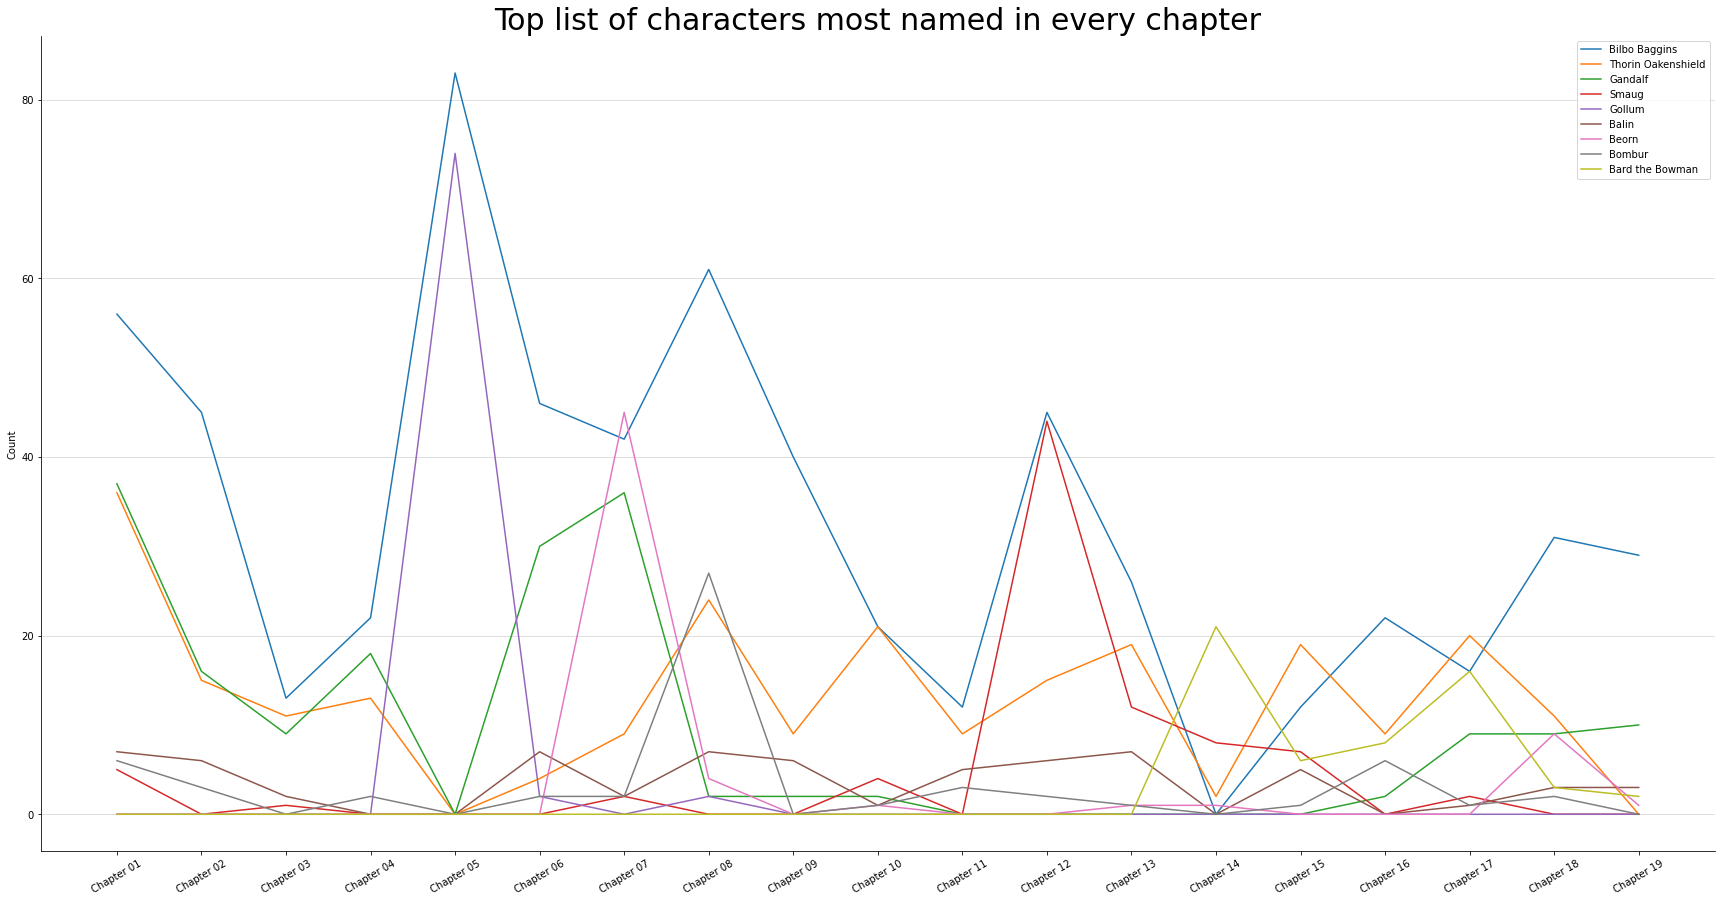

In [140]:
title_graph = 'Top list of characters most named in every chapter'
number_of_characters = 9

fig, ax = plt.subplots(figsize=(30,15))


top_N_frequent_characters = [ name for name, _ in person_counts[:number_of_characters] ]
x = df_grouped['chapter']
y_list = [df_grouped[character].tolist() for character in top_N_frequent_characters]

for i, y in enumerate(y_list):
    ax.plot(x, y, label=top_N_frequent_characters[i])


ax.set_title(title_graph, fontsize=30)
ax.legend()
ax.set_ylabel('Count')
ax.set_xticklabels(x, rotation=30)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(alpha=0.5)

[205, 187, 51, 72, 158, 132, 164, 179, 57, 99, 40, 127, 84, 54, 71, 56, 80, 93, 61]


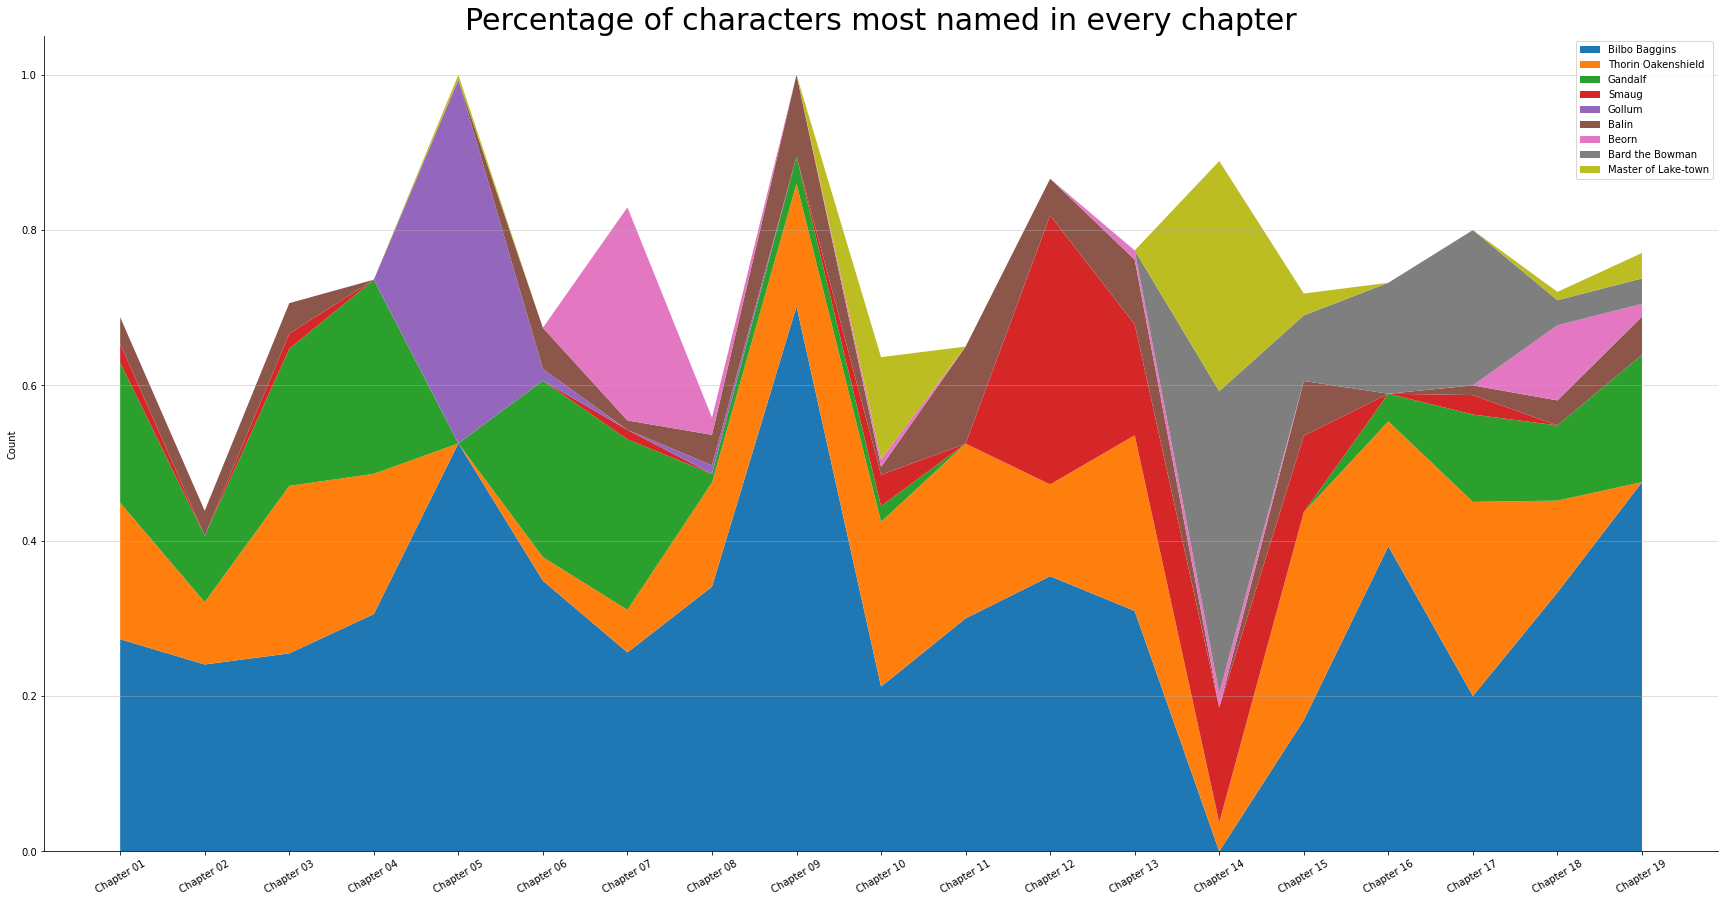

In [148]:
title_graph = 'Percentage of characters most named in every chapter'
number_of_characters = 12

fig, ax = plt.subplots(figsize=(30,15))

top_N_frequent_characters = [ name for name, _ in person_counts[:number_of_characters] ]
top_N_frequent_characters.pop(top_N_frequent_characters.index("Bombur"))
top_N_frequent_characters.pop(top_N_frequent_characters.index("Fili"))
top_N_frequent_characters.pop(top_N_frequent_characters.index("Kili"))

x = df_grouped['chapter']

sum_list = df_grouped['sum'].tolist()
print(sum_list)
y_list = [df_grouped[character].tolist() for character in top_N_frequent_characters]
y_list = [ [n / sum_list[i] for i, n in enumerate(y)] for y in y_list] # normalize the values

ax.stackplot(x, y_list, labels=top_N_frequent_characters)


ax.set_title(title_graph, fontsize=30)
ax.legend()
ax.set_ylabel('Count')
ax.set_xticklabels(x, rotation=30)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(alpha=0.5)

#import numpy as np
#import matplotlib.pyplot as plt
top_N_frequent_characters = [ name for name, _ in person_counts[:9] ]

# Create data
#x=range(1,6)
#y1=[1,4,6,8,9]
#y2=[2,2,7,10,12]
#y3=[2,8,5,10,6]

# Basic stacked area chart.
#plt.stackplot(x, y1, y2, y3, labels=['A','B','C'])
#plt.legend(loc='upper left')

---
# Sentiment Analysis
---

In [156]:
nltk.download('vader_lexicon')
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sid = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


/usr/local/lib/python3.7/dist-packages/nltk/twitter/__init__.py:20: UserWarning: The twython library has not been installed. Some functionality from the twitter package will not be available.
  warnings.warn("The twython library has not been installed. "


In [174]:
# deep copy
copydf = df.copy(deep=True)
copydf

,sentence,chapter,chapter_name,cleaned_sentence,token_list,named_entities,characters,places,sentence_length,orgs,person,characters_matched,characters_cleaned
0,In a hole in the ground there lived a hobbit.,Chapter 01,AN UNEXPECTED PARTY,In a hole in the ground there lived a hobbit,"(In, a, hole, in, the, ground, there, lived, a, hobbit, .)",(),[],[],10,0,0,[],[]
1,"Not a nasty, dirty, wet hole, filled with the ends of worms and an oozy smell, nor yet a dry, bare, sandy hole with nothing in it to sit down on or to eat: it was a hobbit-hole, and that means comfort.",Chapter 01,AN UNEXPECTED PARTY,Not a nasty dirty wet hole filled with the ends of worms and an oozy smell nor yet a dry bare sandy hole with nothing in it to sit down on or to eat it was a hobbit hole and that means comfort,"(Not, a, nasty, ,, dirty, ,, wet, hole, ,, filled, with, the, ends, of, worms, and, an, oozy, smell, ,, nor, yet, a, dry, ,, bare, ,, sandy, hole, with, nothing, in, it, to, sit, down, on, or, to, eat, :, it, was, a, hobbit, -, hole, ,, and, that, means, comfort, .)",(),[],[],42,0,0,[],[]
2,"It had a perfectly round door like a porthole, painted green, with a shiny yellow brass knob in the exact middle.",Chapter 01,AN UNEXPECTED PARTY,It had a perfectly round door like a porthole painted green with a shiny yellow brass knob in the exact middle,"(It, had, a, perfectly, round, door, like, a, porthole, ,, painted, green, ,, with, a, shiny, yellow, brass, knob, in, the, exact, middle, .)",(),[],[],21,0,0,[],[]
3,"The door opened on to a tube-shaped hall like a tunnel: a very comfortable tunnel without smoke, with panelled walls, and floors tiled and carpeted, provided with polished chairs, and lots and lots of pegs for hats and coats—the hobbit was fond of visitors.",Chapter 01,AN UNEXPECTED PARTY,The door opened on to a tube shaped hall like a tunnel a very comfortable tunnel without smoke with panelled walls and floors tiled and carpeted provided with polished chairs and lots and lots of pegs for hats and coats the hobbit was fond of visitors,"(The, door, opened, on, to, a, tube, -, shaped, hall, like, a, tunnel, :, a, very, comfortable, tunnel, without, smoke, ,, with, panelled, walls, ,, and, floors, tiled, and, carpeted, ,, provided, with, polished, chairs, ,, and, lots, and, lots, of, pegs, for, hats, and, coats, —, the, hobbit, was, fond, of, visitors, .)",(),[],[],44,0,0,[],[]
4,"The tunnel wound on and on, going fairly but not quite straight into the side of the hill—The Hill, as all the people for many miles round called it—and many little round doors opened out of it, first on one side and then on another.",Chapter 01,AN UNEXPECTED PARTY,The tunnel wound on and on going fairly but not quite straight into the side of the hill The Hill as all the people for many miles round called it and many little round doors opened out of it first on one side and then on another,"(The, tunnel, wound, on, and, on, ,, going, fairly, but, not, quite, straight, into, the, side, of, the, hill, —, The, Hill, ,, as, all, the, people, for, many, miles, round, called, it, —, and, many, little, round, doors, opened, out, of, it, ,, first, on, one, side, and, then, on, another, .)","((The, Hill),)",[],[The Hill],45,1,0,[],[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5873,"Surely you don't disbelieve the prophecies, because you had a hand in bringing them about yourself?",Chapter 19,THE LAST STAGE,Surely you don t disbelieve the prophecies because you had a hand in bringing them about yourself,"(Surely, you, do, n't, disbelieve, the, prophecies, ,, because, you, had, a, hand, in, bringing, them, about, yourself, ?)",(),[],[],16,0,0,[],[]
5874,"You don't really suppose, do you, that all your adventures and escapes were managed by mere luck, just for your sole benefit?",Chapter 19,THE LAST STAGE,You don t really suppose do you that all your adventures and escapes were managed by mere luck just for your sole benefit,"(You, do, n't, really, suppose, ,, do, 

In [175]:
compound_scores = []
for sentence in copydf['sentence']:
    compound_scores.append(
        (sentence, 
         sid.polarity_scores(sentence)['compound'],
         sid.polarity_scores(sentence)['pos'],
         sid.polarity_scores(sentence)['neg'],
         sid.polarity_scores(sentence)['neu'])
        )

In [176]:
print("\nGOOD SENTENCES:\n")
count = 0
for element in compound_scores:
    if count >= 5:
      break

    if element[1] > 0:
        pprint.pprint(element)
        print("\n")
        count += 1

print("\nBAD SENTENCES:\n")
count = 0
for element in compound_scores:
    if count >= 5:
      break

    if element[1] < 0:
        pprint.pprint(element)
        print("\n")
        count += 1


GOOD SENTENCES:

('Not a nasty, dirty, wet hole, filled with the ends of worms and an oozy '
 'smell, nor yet a dry, bare, sandy hole with nothing in it to sit down on or '
 'to eat: it was a hobbit-hole, and that means comfort.',
 0.7802,
 0.179,
 0.0,
 0.821)


('It had a perfectly round door like a porthole, painted green, with a shiny '
 'yellow brass knob in the exact middle.',
 0.7717,
 0.295,
 0.0,
 0.705)


('The door opened on to a tube-shaped hall like a tunnel: a very comfortable '
 'tunnel without smoke, with panelled walls, and floors tiled and carpeted, '
 'provided with polished chairs, and lots and lots of pegs for hats and '
 'coats—the hobbit was fond of visitors.',
 0.8399,
 0.191,
 0.0,
 0.809)


('No going upstairs for the hobbit: bedrooms, bathrooms, cellars, pantries '
 '(lots of these), wardrobes (he had whole rooms devoted to clothes), '
 'kitchens, dining-rooms, all were on the same floor, and indeed on the same '
 'passage.',
 0.128,
 0.071,
 0.058,
 0.871)


In [177]:
all_scores = []
for element in compound_scores:
    all_scores.append(element[1])

for element in compound_scores:
    if element[1] == max(all_scores):
        print('\nMost positive compound score was assigned to: \n', element)
    elif element[1] == min(all_scores):
        print('\nMost negative compound score assigned to: \n', element)


Most negative compound score assigned to: 
 ('There were lots of dragons in the North in those days, and gold was probably getting scarce up there, with the dwarves flying south or getting killed, and all the general waste and destruction that dragons make going from bad to worse.', -0.9559, 0.0, 0.322, 0.678)

Most positive compound score was assigned to: 
 ('Beorn was most jolly for a change; indeed he seemed to be in a splendidly good humour and set them all laughing with his funny stories; nor did they have to wonder long where he had been or why he was so nice to them, for he told them himself.', 0.9698, 0.353, 0.0, 0.647)


In [178]:
copydf['compound_score'] = [x[1] for x in compound_scores]
copydf['pos_score'] = [x[2] for x in compound_scores]
copydf['neg_score'] = [x[3] for x in compound_scores]
copydf['neu_score'] = [x[4] for x in compound_scores]

In [179]:
copydf

,sentence,chapter,chapter_name,cleaned_sentence,token_list,named_entities,characters,places,sentence_length,orgs,person,characters_matched,characters_cleaned,compound_score,pos_score,neg_score,neu_score
0,In a hole in the ground there lived a hobbit.,Chapter 01,AN UNEXPECTED PARTY,In a hole in the ground there lived a hobbit,"(In, a, hole, in, the, ground, there, lived, a, hobbit, .)",(),[],[],10,0,0,[],[],0.0000,0.000,0.00,1.000
1,"Not a nasty, dirty, wet hole, filled with the ends of worms and an oozy smell, nor yet a dry, bare, sandy hole with nothing in it to sit down on or to eat: it was a hobbit-hole, and that means comfort.",Chapter 01,AN UNEXPECTED PARTY,Not a nasty dirty wet hole filled with the ends of worms and an oozy smell nor yet a dry bare sandy hole with nothing in it to sit down on or to eat it was a hobbit hole and that means comfort,"(Not, a, nasty, ,, dirty, ,, wet, hole, ,, filled, with, the, ends, of, worms, and, an, oozy, smell, ,, nor, yet, a, dry, ,, bare, ,, sandy, hole, with, nothing, in, it, to, sit, down, on, or, to, eat, :, it, was, a, hobbit, -, hole, ,, and, that, means, comfort, .)",(),[],[],42,0,0,[],[],0.7802,0.179,0.00,0.821
2,"It had a perfectly round door like a porthole, painted green, with a shiny yellow brass knob in the exact middle.",Chapter 01,AN UNEXPECTED PARTY,It had a perfectly round door like a porthole painted green with a shiny yellow brass knob in the exact middle,"(It, had, a, perfectly, round, door, like, a, porthole, ,, painted, green, ,, with, a, shiny, yellow, brass, knob, in, the, exact, middle, .)",(),[],[],21,0,0,[],[],0.7717,0.295,0.00,0.705
3,"The door opened on to a tube-shaped hall like a tunnel: a very comfortable tunnel without smoke, with panelled walls, and floors tiled and carpeted, provided with polished chairs, and lots and lots of pegs for hats and coats—the hobbit was fond of visitors.",Chapter 01,AN UNEXPECTED PARTY,The door opened on to a tube shaped hall like a tunnel a very comfortable tunnel without smoke with panelled walls and floors tiled and carpeted provided with polished chairs and lots and lots of pegs for hats and coats the hobbit was fond of visitors,"(The, door, opened, on, to, a, tube, -, shaped, hall, like, a, tunnel, :, a, very, comfortable, tunnel, without, smoke, ,, with, panelled, walls, ,, and, floors, tiled, and, carpeted, ,, provided, with, polished, chairs, ,, and, lots, and, lots, of, pegs, for, hats, and, coats, —, the, hobbit, was, fond, of, visitors, .)",(),[],[],44,0,0,[],[],0.8399,0.191,0.00,0.809
4,"The tunnel wound on and on, going fairly but not quite straight into the side of the hill—The Hill, as all the people for many miles round called it—and many little round doors opened out of it, first on one side and then on another.",Chapter 01,AN UNEXPECTED PARTY,The tunnel wound on and on going fairly but not quite straight into the side of the hill The Hill as all the people for many miles round called it and many little round doors opened out of it first on one side and then on another,"(The, tunnel, wound, on, and, on, ,, going, fairly, but, not, quite, straight, into, the, side, of, the, hill, —, The, Hill, ,, as, all, the, people, for, many, miles, round, called, it, —, and, many, little, round, doors, opened, out, of, it, ,, first, on, one, side, and, then, on, another, .)","((The, Hill),)",[],[The Hill],45,1,0,[],[],-0.3235,0.000,0.05,0.950
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5873,"Surely you don't disbelieve the prophecies, because you had a hand in bringing them about yourself?",Chapter 19,THE LAST STAGE,Surely you don t disbelieve the prophecies because you had a hand in bringing them about yourself,"(Surely, you, do, n't, disbelieve, the, prophecies, ,, because, you, had, a, hand, in, bringing, them, about, yourself, ?)",(),[],[],16,0,0,[],[],0.7899,0.400,0.00,0.600
5874,"You don't really suppose, do you, that all your adventures and escapes were managed by mere luck, just for yo

In [187]:
df_grouped = copydf.groupby('chapter', as_index=True).mean()
df_grouped

,sentence_length,orgs,person,compound_score,pos_score,neg_score,neu_score
chapter,,,,,,,
Chapter 01,16.613462,0.094231,0.225000,0.099594,0.090585,0.043481,0.865935
Chapter 02,14.289617,0.051913,0.344262,0.001803,0.057077,0.063464,0.879470
Chapter 03,15.216931,0.047619,0.116402,0.114608,0.108984,0.030323,0.860688
Chapter 04,16.875000,0.050000,0.145833,-0.036795,0.066363,0.082967,0.850688
Chapter 05,12.457961,0.033989,0.041145,-0.043171,0.064868,0.096669,0.838470
Chapter 06,17.367876,0.069948,0.152850,-0.019478,0.072117,0.079505,0.848355
Chapter 07,16.297641,0.156080,0.166969,0.059074,0.073802,0.053341,0.872862
Chapter 08,18.550091,0.078324,0.194900,-0.032996,0.066342,0.086291,0.847377
Chapter 09,20.065517,0.027586,0.058621,0.017253,0.071303,0.081048,0.847655


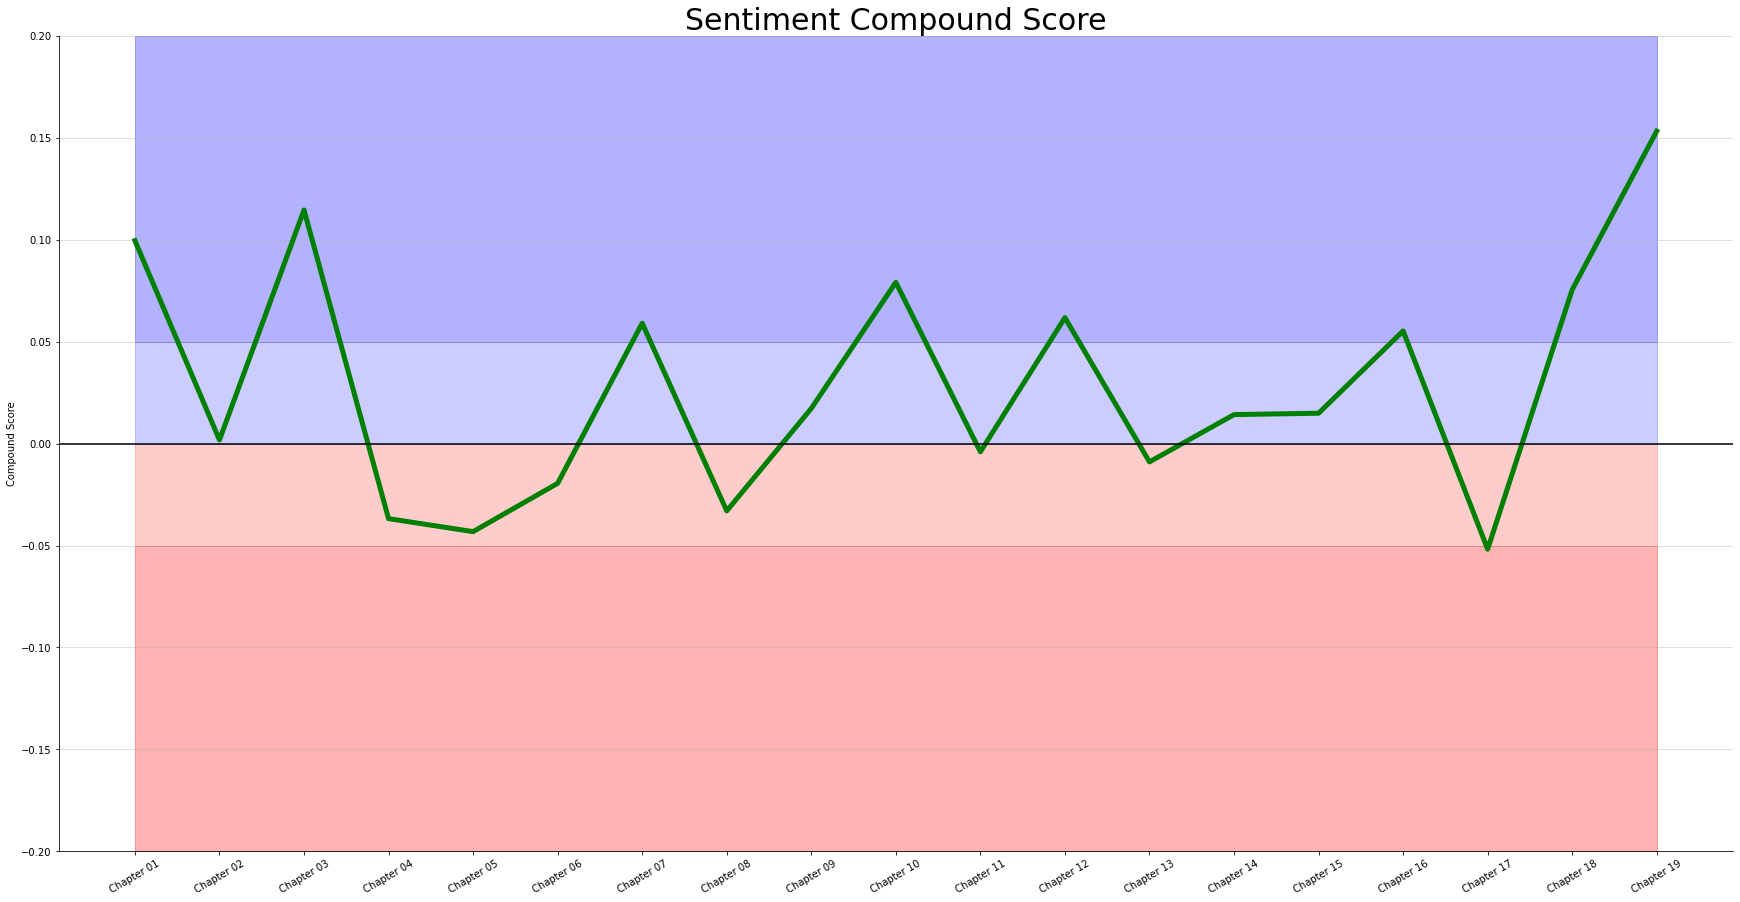

In [198]:
title_graph = 'Sentiment Compound Score'

fig, ax = plt.subplots(figsize=(30,15))

x = df_grouped['compound_score'].index
y = df_grouped['compound_score'].values
ax.plot(x, y, linewidth=5, color="green")

ax.set_ylim(-0.2, 0.2)

ax.axhline(y=0, color='black')
ax.fill_between(x=ax.get_xticks(), y1=0.05, y2=0.2, color='blue', alpha=0.3)
ax.fill_between(x=ax.get_xticks(), y1=0, y2=0.05, color='blue', alpha=0.2)
ax.fill_between(x=ax.get_xticks(), y1=0, y2=-0.05, color='red', alpha=0.2)
ax.fill_between(x=ax.get_xticks(), y1=-0.05, y2=-0.2, color='red', alpha=0.3)

ax.set_title(title_graph, fontsize=30)
ax.set_ylabel('Compound Score')
ax.set_xticklabels(x, rotation=30)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(alpha=0.5)